# Superpixel-Based Unsupervised PCA Methods for Hyperspectral Image Classification  
*Shubhranil Chatterjee*  

This project explores dimensionality reduction techniques for hyperspectral images (HSIs), focusing on superpixel-based approaches such as **SuperPCA** and **S3-PCA**. These methods utilize spatial-spectral segmentation (e.g., ERS and SLIC) to form meaningful clusters and extract localized low-dimensional representations for improved classification performance.

In addition to replicating experiments from the original paper, we further evaluate the impact of:
- Segmentation technique (ERS on principal projection vs. full HSI, and SLIC),
- Reconstruction criteria (spectral, spatial, and combined proximity),
- Parameter tuning for optimal performance.

All code, data, and results are part of the course project for **IE506 - Machine Learning Principles and Techniques**, conducted at **IIT Bombay** in 2025.


Load required libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib.colors import BoundaryNorm
import scipy
from scipy.sparse import lil_matrix
from sklearn import metrics, svm
from sklearn.model_selection import GridSearchCV
%config InlineBackend.figure_format='retina'

Entropy Rate Superpixel Segmentation

In [2]:
class Node:
    """
    Class representing a node in the image graph.
    
    Each node corresponds to a pixel in the image.
    
    Attributes :
        x (int) : Column index of the pixel
        y (int) : Row index of the pixel
        intensity (float (n,)) : Array of intensities in each spectral band
        index (int) : Index for referencing in graph algorithms
        
    """
    
    def __init__(self, i, j, I, index = None):
        self.x = i 
        self.y = j 
        self.intensity = I 
        self.index = index
        
    
    def __str__(self):
        return f"Node(x={self.x}, y={self.y}, intensity={self.intensity}, index={self.index})"
    
    def __repr__(self):
        return f"Node(x={self.x}, y={self.y}, intensity={self.intensity}, index={self.index})"

In [3]:
class Edge:
    """
    Class representing an edge in the image graph.
    
    Each edge connects two nodes (pixels). One of the nodes is assigned as the owner and the other as the neighbor.
    
    Attributes :
        owner (int) : Index of the owner node
        neighbor (int) : Index of the neighbor node
        weight (float) : Weight assigned to the edge based on spectral spectral proximity of its nodes
        index (int) : Index for referencing in graph algorithms
        
    """
    def __init__(self, owner, neighbor, weight, index = None):
        self.owner = owner
        self.neighbor = neighbor
        self.weight = weight
        self.index = index
                    
    def __str__(self):
        return f"Edge(owner={self.owner}, neighbor={self.neighbor}, weight={self.weight}, index={self.index})"
    
    def __repr__(self):
        return f"Edge(owner={self.owner}, neighbor={self.neighbor}, weight={self.weight}, index={self.index})"
        

In [4]:
def gaussian_kernel(owner, neighbor, **kernel_args):
    """
    Function to compute edge weights using the gaussian kernel
    
    """
    
    sigma = kernel_args.get('sigma', 5.0)
    
    # Spatial proximity
    d = np.sqrt(((owner.x-neighbor.x))**2 + ((owner.y-neighbor.y))**2)
    
    # Spectral proximity
    i = np.linalg.norm(owner.intensity - neighbor.intensity)
    
    return np.exp(-((d * i) ** 2) / (2 * sigma ** 2))

In [5]:
class ImgGraph:
    """ 
    Class representing a graph constructed from an image, where each pixel is a node 
    and edges connect neighboring pixels.
    
    The graph supports both 4- and 8-connectivity, and edge weights are computed using a 
    user-defined kernel function (only Gaussian kernel implemented).
    
    Attributes:
        image (ndarray): Input image, potentially multi-spectral (shape: rows x cols x bands).
        rows (int): Number of rows (height) in the image.
        cols (int): Number of columns (width) in the image.
        n (int): Total number of nodes (pixels) in the graph.
        nEdges (int): Total number of edges based on the connectivity.
        V (Node (n,)): Array of Node objects.
        E (Edge (nEdges,)): Array of Edge objects.
        edgesV ([] (n,)): List of edge indices connected to each node.
        W_V (float (n,)): Total incident weight at each node (used in spectral methods).
        W_T (float): Total sum of all edge weights in the graph.

    """
    
    def __init__(self, image, kernel, conn8 = False, **kernel_args):
        
        """
        Initializes the image graph.

        Args:
            image (ndarray): Input image.
            kernel (function): A function that takes two Node objects and returns a scalar weight.
            conn8 (bool): Whether to use 8-connectivity (default is 4-connectivity).
            **kernel_args: Additional arguments to pass to the kernel function.
            
        """
        
        self.image = image
        self.rows, self.cols = self.image.shape[0:2]
        self.n = self.rows*self.cols
        
        if conn8 is True:
            # Define 8-neighbor connectivity (sw, s, se, w, e, nw, n, ne)
            neighbors = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
            self.nEdges = self.rows*(self.cols-1) + self.cols*(self.rows-1) + 2*(self.rows-1)*(self.cols-1)
        else:
            # Define 4-neighbor connectivity (s, w, e, n)
            neighbors = [(-1,0), (0, -1), (0, 1), (1, 0)]
            self.nEdges = self.rows*(self.cols-1) + self.cols*(self.rows-1)
        
        
        # Initialize vertices array
        self.V = np.empty(self.n, dtype=object)
        
        # Initialize edges array
        self.E = np.empty(self.nEdges, dtype=object)
        
        # Counter for number of edges added
        nEdgesAdded = 0 
        
        # Array of indices of edges connected to vertices
        self.edgesV = np.empty(self.n, dtype=object)
        
        for i in range(self.n):
            self.edgesV[i] = []     
        
        # Initialize array of total incident weights at vertices
        self.W_V = np.zeros(self.n, dtype=float)
        
        # Assemble graph
        
        # Add nodes 
        for i in range(self.rows):
            for j in range(self.cols):
                ind = i*self.cols + j
                self.V[ind] = Node(j,i,self.image[i,j,...],index=ind)
        
        # Add edges 
        for i in range(self.rows):
            for j in range(self.cols):
                ind = i*self.cols + j
            
                for dx, dy in neighbors:
                    # Coordinates of neighbor node
                    ni, nj = i + dx, j + dy
                
                    if 0 <= ni < self.rows and 0 <= nj < self.cols:
                        # Index of neighbor node
                        nind = ni*self.cols + nj
                        
                        if ind < nind: # to ensure that edge is added only once
                            
                            # Compute edge weight
                            w = kernel(self.V[ind], self.V[nind], **kernel_args)

                            # Add weight to total incident weight at both nodes
                            self.W_V[ind] += w
                            self.W_V[nind] += w
                            
                            # Add edge
                            self.E[nEdgesAdded] = Edge(self.V[ind], self.V[nind], w, index = nEdgesAdded)
                            
                            # Add edge index to list of edges connected to each of the two nodes
                            self.edgesV[ind].append(nEdgesAdded)
                            self.edgesV[nind].append(nEdgesAdded)
                            
                            nEdgesAdded += 1
        
        # Check whether number of edges added is correct                   
        assert nEdgesAdded == self.nEdges, f"Expected {self.nEdges}, got {nEdgesAdded}"

        # Compute sum of weights of all edges (used for normalization later)
        self.W_T = np.sum(self.W_V)


In [6]:
class ERS():
    """ 
    ------------------------------------------------------------------------------------
    ERS (Entropy Rate Superpixel Segmentation) Algorithm Implementation
    ------------------------------------------------------------------------------------
    
    This class implements the ERS algorithm, a graph based segmentation method that partitions
    an image into a specified number (K) of superpixels, or clusters of connected pixels.
    
    The image is represented as a weighted graph where nodes are pixels and edges connect 
    neighboring pixels based on similarity (in this case, spectral proximity for hyperspectral images ).
    
    The optimization algorithm greedily selects edges to merge clusters, maximizing a combined 
    objective: Entropy Rate Gain (encourages homogeneity within clusters) and a
    Balancing Gain (promotes uniform region sizes).
    
    Methods:
        initialize : Constructs the graph from the image and initializes node/edge properties.
        setParams : Sets K (target number of superpixels) and alpha (weight given to balancing gain), and 
                computes initial edge gains.
        ERGain / BGain : Compute the respective gains to the objective when a given edge is selected.
        segment : Main loop where regions are iteratively merged by selecting the edge with the highest gain, 
                updating the corresponding labels and gain values, until only K clusters remain.
    
    Output:
        labels_matrix : A 2D array with the same dimensions as the input image, where each pixel 
        is labeled by its corresponding superpixel index.
        
    Usage:
        1. Instantiate: ers = ERS()
        2. Initialize: ers.initialize(image, kernel)
        3. Set parameters and compute initial gains: ers.setParams(K=desired_superpixels, alpha=balancing_weight)
        4. Run segmentation iterations: ers.segment()
        
    """
    def initialize(self, image, kernel, conn8 = False, **kernel_args):
        """ 
        Args:
            image (ndarray): Input image.
            kernel (function): A function that takes two Node objects and returns a scalar weight.
            conn8 (bool): Whether to use 8-connectivity (default is 4-connectivity).
            **kernel_args: Additional arguments to pass to the kernel function.
            
        """
        # Create an ImgGraph object for the image
        self.imgGraph = ImgGraph(image, kernel, conn8, **kernel_args)
        
        # Initialize an array that will store 1 if edge with given index is selected  
        self.edges_added = np.zeros(self.imgGraph.nEdges, dtype=int)
        
        # Initialize array of labels each node belongs to (Initially each node has unique label)
        self.labels = np.arange(0,self.imgGraph.n)
        
        # Initialize self weights (normalized) of nodes (this needs to be updated each time an edge is added to A)
        self.selfW = self.imgGraph.W_V / self.imgGraph.W_T
        
        # Initialize edge weights (normalized)
        self.edgeW = np.array([e.weight for e in self.imgGraph.E]) / self.imgGraph.W_T
    
    def setParams(self, K, alpha):
        """ 
        Args:
            K (int): Desired number of superpixels
            alpha (float): Weight given to balancing gain
            
        """
        self.K = K 
        
        ERGains = np.zeros(self.imgGraph.nEdges, dtype=float)
        BGains = np.zeros(self.imgGraph.nEdges, dtype=float)
        
        # Compute initial weights for all edges
        for e in self.imgGraph.E:
            edgeIndex = e.index
            ERGains[edgeIndex] = self.ERGain(edgeIndex)
            BGains[edgeIndex] = self.BGain(edgeIndex)
        
        self.alpha = alpha
        
        beta = np.max(ERGains)/np.max(BGains)
        
        # Compute corrected balancing weight based on data
        self.alphaCorr = alpha*beta*K

        self.gains = ERGains + self.alphaCorr*BGains
        
    def ERGain(self, edgeIndex):
        """ 
            Compute the Entropy Rate gain for an edge.
        """
        
        # If edge has already been added, return -1e6 (i.e. it should not be added)
        if self.edges_added[edgeIndex] == 1:
            return -1e6
        
        # Get labels for both nodes of the edge
        i = self.imgGraph.E[edgeIndex].owner.index
        j = self.imgGraph.E[edgeIndex].neighbor.index
        
        label_i = self.labels[i]
        label_j = self.labels[j]
        
        # Check if the nodes belong to different labels, otherwise return -1e6 (i.e. it should not be added, as it will lead to cycles)
        if label_i == label_j:
            return -1e6
        
        c_i = self.selfW[i]
        c_j = self.selfW[j]
        w_ij = self.edgeW[edgeIndex]
        
        eps = 1e-8
        
        H_old = -c_i*np.log2(c_i+eps) -c_j*np.log2(c_j+eps)
        H_new = -(c_i-w_ij)*np.log2(c_i-w_ij+eps) -(c_j-w_ij)*np.log2(c_j-w_ij+eps) -2*w_ij*np.log2(w_ij+eps)
        H_gain = (H_new - H_old)
        
        if np.isnan(H_gain):
            H_gain = -1e6
            
        return H_gain
    
    def BGain(self, edgeIndex):
        """ 
            Compute the Balancing gain for an edge.
        """
        
        # If edge has already been added, return -1e6 (i.e. it should not be added)
        if self.edges_added[edgeIndex] == 1:
            return -1e6
        
        # Get labels for both nodes of the edge    
        i = self.imgGraph.E[edgeIndex].owner.index
        j = self.imgGraph.E[edgeIndex].neighbor.index
        
        label_i = self.labels[i]
        label_j = self.labels[j]
        
        # Check if the nodes belong to different labels, otherwise return -1e6 (i.e. it should not be added, as it will lead to cycles)
        if label_i == label_j:
            return -1e6
        
        # Get number of nodes in each of the superpixels
        count_i = np.sum(self.labels == label_i)
        count_j = np.sum(self.labels == label_j)
        
        # Normalize
        S_i = count_i*1.0/self.imgGraph.n
        S_j = count_j*1.0/self.imgGraph.n
        
        B_gain = (- (S_i+S_j)*np.log2(S_i+S_j) + S_i*np.log2(S_i) + S_j*np.log2(S_j)) +     1
        
        if np.isnan(B_gain):
            B_gain = -1e6
            
        return B_gain

    def segment(self, debug = 0):
        """ 
        Function that performs the segmentation iterations
        """
        
        self.nSupPix = self.imgGraph.n # Initially, all nodes are disconnected
        
        while self.nSupPix > self.K:
            
            # Get edge index with maximum gain
            maxGainEdgeIndex = np.argmax(self.gains)
            if debug == 1:
                print("\nNumber of clusters:", self.nSupPix)
                print("\nMax Gain: ",self.gains[maxGainEdgeIndex])
            
            if (self.gains[maxGainEdgeIndex] <= 0):
                break
            
            # Add edge to set 
            self.edges_added[maxGainEdgeIndex] = 1
            
            # Update gain of edge to -1e6 (so that it is not considered anymore)
            self.gains[maxGainEdgeIndex] = -1e6
            
            # Get index of owner and neighbor nodes
            owner = self.imgGraph.E[maxGainEdgeIndex].owner.index
            neighbor = self.imgGraph.E[maxGainEdgeIndex].neighbor.index
            
            # Get labels of owner and neighbor nodes
            owner_label = self.labels[owner]
            neighbor_label = self.labels[neighbor]
            
            # Change labels of all nodes having neighbor label to owner label
            self.labels[self.labels == neighbor_label] = owner_label
            
            # Update self weights of owner and neighbor nodes
            self.selfW[owner] -= self.edgeW[maxGainEdgeIndex]
            self.selfW[neighbor] -= self.edgeW[maxGainEdgeIndex]
            
            # Update gains for all edges connecting nodes that were in the two segments
            nodes_to_update = np.arange(self.imgGraph.n)[(self.labels == owner_label)]
            
            for nodeIndex in nodes_to_update:
                # Get indices of edges connecting each node
                edges = self.imgGraph.edgesV[nodeIndex]
                
                for edgeIndex in edges:
                    if edgeIndex != maxGainEdgeIndex:
                        ERGain_ = self.ERGain(edgeIndex)
                        BGain_ = self.BGain(edgeIndex)
                        self.gains[edgeIndex] = ERGain_ + self.alphaCorr*BGain_

            self.nSupPix = len(np.unique(self.labels))

        # Once the clustering is done, change labels such that they are from 0 to K-1.
        unique_labels = np.unique(self.labels)
        new_labels = np.arange(0, len(unique_labels))
        
        self.updated_labels = self.labels.copy()
        for i in range(len(unique_labels)):
            self.updated_labels[self.labels == unique_labels[i]] = new_labels[i]
        
        # Reshape into the same shape as the image
        self.labels_matrix = self.updated_labels.reshape(self.imgGraph.rows,self.imgGraph.cols)
        
        print(f"Successfully segmented the image into {self.nSupPix} superpixels.")
            

S3-PCA 

In [232]:
def pca(X, nComponents, center = True):
    '''
        Function to get the principal components for a data matrix.
        
        The data matrix X consists of sample rows and feature columns.
        
        Args:
            nComponents (int): Number of principal components to output
            center (bool): Flag for whether to center data before performing SVD
            (if False, assumption is that data is already centered)
    '''
    
    import numpy as np
    
    if center:
        mean_sample = np.mean(X, axis=0, keepdims=True)
        
        X_centered = X - mean_sample
    
        U, S, VT = np.linalg.svd(X_centered, full_matrices=False)
    
        components = VT[:nComponents,:]

        projected_X = X @ components.T
        
    else:
        U, S, VT = np.linalg.svd(X, full_matrices=False)

        components = VT[:nComponents,:]
        
        projected_X = X @ components.T
        
    # Pad with zeros if fewer components were returned. 
    # This occurs when the number of pixels in the superpixel is less than the desired number of components.
    if projected_X.shape[1] < nComponents:
        n_samples = projected_X.shape[0]
        n_missing = nComponents - projected_X.shape[1]
        padding = np.zeros((n_samples, n_missing))
        projected_X = np.hstack((projected_X, padding))
        
    return projected_X, components

In [7]:
def fixed_split(X, y, train_samples_per_class, random_seed):
    """
    Function to split dataset into training and test data with fixed number of training samples for each label.
    
    For classes which have less samples than required, only half the samples are added to the training set.
    """
    
    X_train, X_test, y_train, y_test , indices_train, indices_test = [], [], [], [], [], []
    
    unique_labels = np.unique(y)
    
    for label in range(1,np.max(unique_labels)+1):
        indices = np.where(y == label)[0]  # Get all indices for the current label
        
        n_train = np.minimum(train_samples_per_class, int(np.floor(len(indices)/2)))

        np.random.seed(random_seed)
        # Shuffle indices randomly
        np.random.shuffle(indices)

        # Split into train and test
        train_indices = indices[:n_train]
        test_indices = indices[n_train:]

        # Append to train/test lists
        X_train.append(X[train_indices,:])
        X_test.append(X[test_indices,:])
        y_train.append(y[train_indices])
        y_test.append(y[test_indices])
        indices_train.append(train_indices)
        indices_test.append(test_indices)

    # Stack results
    X_train, X_test = np.vstack(X_train), np.vstack(X_test)
    y_train, y_test = np.hstack(y_train), np.hstack(y_test)
    indices_train, indices_test = np.hstack(indices_train), np.hstack(indices_test)
    
    return X_train, X_test, y_train, y_test, indices_train, indices_test

In [317]:
class S3PCA:
    
    def initialize(self, data3Darr, labelsMat):
        self.data3Darr = data3Darr
        self.labelsMat = labelsMat
        self.nY = data3Darr.shape[0]
        self.nX = data3Darr.shape[1]
        self.nBands = data3Darr.shape[2]
        self.nPix = self.nX*self.nY
        self.min_label = np.min(labelsMat)
        self.max_label = np.max(labelsMat)

        self.dataMat = data3Darr.reshape(self.nPix, self.nBands) #np.zeros((nPix, nBands)) #
        
        self.norms = np.linalg.norm(self.dataMat, axis=1)
        self.std_norm = np.std(self.norms)
        
        self.labelsVec = labelsMat.reshape(self.nPix)

        # Get first principal component 
        X_pca, components = pca(self.dataMat, 1)
        # Reshape into 2D image
        self.img_pca = X_pca.reshape(self.nY,self.nX)
        
    def segment(self, S, method, use_pca = True, **kwargs):
            
        if use_pca is True:
            img = self.img_pca
            std = np.std(img)
            
        else:
            img = self.data3Darr
            std = self.std_norm
            
        if method == "ERS":
            ers = ERS()
            ers.initialize(img, kernel=gaussian_kernel, sigma = std)
            ers.setParams(S, alpha=0.5)
            ers.segment()
            
            self.segments = ers.labels_matrix
            self.nSegments = len(np.unique(self.segments))
            self.segmentsVec = self.segments.reshape(self.nPix)
            
        if method == "SLIC":  
            from skimage.segmentation import slic
            sigma = kwargs['sigma']
            compactness = kwargs['compactness']
            
            self.segments = slic(self.img_pca, channel_axis=None, n_segments=S, sigma=sigma, compactness=compactness,start_label=0)
            self.nSegments = len(np.unique(self.segments)) 
            self.segmentsVec = self.segments.reshape(self.nPix)
            print(f"Successfully segmented the image into {self.nSegments} superpixels.")

    def superpixelwiseDataMatFromGlobalDataMat(self):        
        """ 
        Function to construct superpixelwise data matrices from the global data matrix.
        
        Returns a list of data matrices corresponding to different superpixel index, 
        and a list of arrays storing the global indices of each pixel in the superpixel matrix.
        
        """

        self.superpixelwise_dataMat_array = []
        self.superpixelwise_indexVec_array = []

    
        for i in range(0,self.nSegments):
            segmentiMat =  np.empty((0, self.nBands))
            segmentiIndicesVec =  np.array([])
            self.superpixelwise_dataMat_array.append(segmentiMat)
            self.superpixelwise_indexVec_array.append(segmentiIndicesVec)
    
        for i in range(0,self.nPix):
            self.superpixelwise_dataMat_array[int(self.segmentsVec[i])] = np.vstack([self.superpixelwise_dataMat_array[self.segmentsVec[i]], self.dataMat[i,:]])
            self.superpixelwise_indexVec_array[int(self.segmentsVec[i])] = np.append(self.superpixelwise_indexVec_array[int(self.segmentsVec[i])], int(i))

    def reconstructSuperpixelDataMat(self, superpixel_dataMat,superpixel_indexVec, k, criterion):
        """ 
        Function to reconstruct the spectral information of each pixel based on its 
        nearest neighboring pixels within the same superpixel.
        
        Args:
            superpixelwise_dataMat (ndarray): Array with spectral information for all pixels in the superpixel.
            superpixelwise_indexVec (ndarray): Array with indices in the flattened image for each pixel in the superpixel.
            nX (int): Number of columns in the image.
            k (int): Number of nearest neighbors to consider for reconstruction.
            criterion: The proximity criterion used for deciding weights given to neighboring pixels in reconstruction.
                "spectral" - Reconstruct based on spectral similarity.
                "spatial" - Reconstruct based on spatial proximity.
        
        """
        if k == 0:
            return superpixel_dataMat
    
        # Compute the distance matrix 
        distMat = EuDist2Mat(superpixel_indexVec, self.nX)
    
        # Get the indices of the smallest k values in each row (i.e. the k nearest pixels)
        sorted_indices = np.argsort(distMat, axis=1)[:, :k+1]  
    
        weightMat = lil_matrix(distMat.shape)
    
        # Populate only the smallest k values in the sparse matrix
        for i in range(distMat.shape[0]):
            
            # Reconstruct based on spectral proximity
            if criterion == "spectral":
                temp = np.sum((superpixel_dataMat[i,:] - superpixel_dataMat[sorted_indices[i],:])**2,axis=1)
                
            # Reconstruct based on spatial proximity
            if criterion == "spatial":
                temp = np.sum((distMat[i,:] - distMat[sorted_indices[i],:])**2,axis=1)
            
            # Reconstruct based on combined criterion
            if criterion == "combined":
                temp = np.sum((distMat[i,:] - distMat[sorted_indices[i],:])**2,axis=1)*np.sum((superpixel_dataMat[i,:] - superpixel_dataMat[sorted_indices[i],:])**2,axis=1)
                
            t = 1/k*np.sum(temp)
            
            weightMat[i,sorted_indices[i]] = np.exp(-temp/(2*t))/np.sum(np.exp(-temp/(2*t)))

        # Convert to CSR format for efficient matrix multiplication
        weightMat = weightMat.tocsr()   
    
        return weightMat @ superpixel_dataMat

    def reconstructSuperpixelwiseDataMat(self, k, reconstruction_criterion = "spectral"):
        self.superpixelwise_reconstructedDataMat_array = []
        for i in range(self.nSegments):
            self.superpixelwise_reconstructedDataMat_array.append(self.reconstructSuperpixelDataMat(self.superpixelwise_dataMat_array[i],self.superpixelwise_indexVec_array[i],k,reconstruction_criterion))
        self.reconstructedDataMat = self.globalDataMatFromSuperpixelwiseDataMat(self.superpixelwise_reconstructedDataMat_array)
        
    def globalDataMatFromSuperpixelwiseDataMat(self, superpixelwise_dataMat_array):
        """
            Function to reassemble the global data matrix from the superpixelwise data matrices.
        """
    
        globalDataMat = np.zeros((self.nPix,superpixelwise_dataMat_array[0].shape[1]))
    
        for i in range(0,self.nSegments):
            for j in range(0,len(self.superpixelwise_indexVec_array[i])):
                pixel_index = int(self.superpixelwise_indexVec_array[i][j])
                globalDataMat[pixel_index,:] = superpixelwise_dataMat_array[i][j,:]
                
        return globalDataMat    

    def reduceAndAssemble(self, nComponents):
        self.superpixelwise_reducedDataMat_array = []
        for i in range(0,self.nSegments):
            segmenti_dataMatReduced, components = pca(self.superpixelwise_reconstructedDataMat_array[i], nComponents)
            self.superpixelwise_reducedDataMat_array.append(segmenti_dataMatReduced)
            
        self.superpixelwiseReducedDataMat = self.globalDataMatFromSuperpixelwiseDataMat(self.superpixelwise_reducedDataMat_array)
    
        globalReducedMat, components = pca(self.reconstructedDataMat, nComponents)

        intermediateDataMat = np.hstack((globalReducedMat, self.superpixelwiseReducedDataMat))

        self.reducedDataMat, components = pca(intermediateDataMat, nComponents)  
            
    def performClassification(self, nSamples, random_seed = 1):
        from sklearn import metrics, svm
        from sklearn.model_selection import GridSearchCV

        # Split data into 30 training samples per label and remaining test samples
        X_train, X_test, y_train, y_test, train_idx, test_idx = fixed_split(self.reducedDataMat, self.labelsVec, nSamples, random_seed)
        
        # Create a classifier: a support vector classifier
        clf = svm.SVC(kernel = 'rbf')

        # Define parameter grid
        param_grid = {'gamma': [0.01, 0.1, 0.3, 0.7, 1, 5, 10, 15, 20, 30, 40, 50, 100, 200], 'C': [0.1, 0.3, 1, 3, 1e1, 3e1, 1e2, 3e2, 7e2, 1e3]}

        # Use GridSearchCV
        cv = 10
        if nSamples < 10:
            cv = int(nSamples / 2)
            
        grid_search = GridSearchCV(clf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        gamma = grid_search.best_params_['gamma']
        C = grid_search.best_params_['C']

        clf = svm.SVC(kernel='rbf',C=C,gamma=gamma)
        clf.fit(X_train, y_train)

        # Predict the value of the digit on the test subset
        predicted = clf.predict(X_test)

        # Generate classification report
        report = metrics.classification_report(y_test, predicted, output_dict=True)

        # Extract overall accuracy
        self.overall_accuracy = report["accuracy"]
        
        self.labelsVec_predicted = np.zeros(self.nPix)

        self.labelsVec_predicted[self.labelsVec != 0] = clf.predict(self.reducedDataMat[self.labelsVec != 0,:])

        self.labels2D_array_predicted = self.labelsVec_predicted.reshape(self.nY,self.nX)

In [10]:
def EuDist2(i1, i2, nX):
    """ 
    Function to find distance between two pixel indices.
    
    Args:
        i1 (int): Index of first pixel in flattened array
        i2 (int): Index of second pixel in flattened array
        nX (int): Number of columns in the image
    
    """
    
    x1 = i1 % nX
    y1 = i1 // nX
    
    x2 = i2 % nX
    y2 = i2 // nX
    
    return (x1-x2)**2 + (y1-y2)**2

In [11]:
def EuDist2Mat(indices, nX):
    """ 
    Function to find the distance matrix.
    
    The element (i, j) in the distance matrix is the distance between the pixels 
    with indices i and j in the flattened image.
    
    """
    d = np.zeros((len(indices),len(indices)))
    
    for i in range(len(indices)):
        d[i,:] = EuDist2(indices[i],indices,nX)
        
    return d

SuperPCA

In [197]:
class SuperPCA:
    def initialize(self, data3Darr, labelsMat):
        self.data3Darr = data3Darr
        self.labelsMat = labelsMat
        self.nY = data3Darr.shape[0]
        self.nX = data3Darr.shape[1]
        self.nBands = data3Darr.shape[2]
        self.nPix = self.nX*self.nY
        self.min_label = np.min(labelsMat)
        self.max_label = np.max(labelsMat)

        self.dataMat = data3Darr.reshape(self.nPix, self.nBands) #np.zeros((nPix, nBands)) #
        
        self.norms = np.linalg.norm(self.dataMat, axis=1)
        self.std_norm = np.std(self.norms)
        
        self.labelsVec = labelsMat.reshape(self.nPix)

        # Get first principal component 
        X_pca, components = pca(self.dataMat, 1)
        # Reshape into 2D image
        self.img_pca = X_pca.reshape(self.nY,self.nX)
        
    def segment(self, S, method, use_pca = True, **kwargs):
            
        if use_pca is True:
            img = self.img_pca
            std = np.std(img)
            
        else:
            img = self.data3Darr
            std = self.std_norm
            
        if method == "ERS":
            ers = ERS()
            ers.initialize(img, kernel=gaussian_kernel, sigma = std)
            ers.setParams(S, alpha=0.5)
            ers.segment()
            
            self.segments = ers.labels_matrix
            self.nSegments = len(np.unique(self.segments))
            self.segmentsVec = self.segments.reshape(self.nPix)
            
        if method == "SLIC":  
            from skimage.segmentation import slic
            sigma = kwargs['sigma']
            compactness = kwargs['compactness']
            
            self.segments = slic(self.img_pca, channel_axis=None, n_segments=S, sigma=sigma, compactness=compactness,start_label=0)
            self.nSegments = len(np.unique(self.segments)) 
            self.segmentsVec = self.segments.reshape(self.nPix)
            print(f"Successfully segmented the image into {self.nSegments} superpixels.")
            
    def superpixelwiseDataMatFromGlobalDataMat(self):        
        """ 
        Function to construct superpixelwise data matrices from the global data matrix.
        
        Returns a list of data matrices corresponding to different superpixel index, 
        and a list of arrays storing the global indices of each pixel in the superpixel matrix.
        
        """

        self.superpixelwise_dataMat_array = []
        self.superpixelwise_indexVec_array = []

    
        for i in range(0,self.nSegments):
            segmentiMat =  np.empty((0, self.nBands))
            segmentiIndicesVec =  np.array([])
            self.superpixelwise_dataMat_array.append(segmentiMat)
            self.superpixelwise_indexVec_array.append(segmentiIndicesVec)
    
        for i in range(0,self.nPix):
            self.superpixelwise_dataMat_array[int(self.segmentsVec[i])] = np.vstack([self.superpixelwise_dataMat_array[self.segmentsVec[i]], self.dataMat[i,:]])
            self.superpixelwise_indexVec_array[int(self.segmentsVec[i])] = np.append(self.superpixelwise_indexVec_array[int(self.segmentsVec[i])], int(i))
            
    def globalDataMatFromSuperpixelwiseDataMat(self, superpixelwise_dataMat_array):
        """
            Function to reassemble the global data matrix from the superpixelwise data matrices.
        """
    
        globalDataMat = np.zeros((self.nPix,superpixelwise_dataMat_array[0].shape[1]))
    
        for i in range(0,self.nSegments):
            for j in range(0,len(self.superpixelwise_indexVec_array[i])):
                pixel_index = int(self.superpixelwise_indexVec_array[i][j])
                globalDataMat[pixel_index,:] = superpixelwise_dataMat_array[i][j,:]
                
        return globalDataMat   
    
    def reduceAndAssemble(self, nComponents):
        self.superpixelwise_reducedDataMat_array = []
        for i in range(0,self.nSegments):
            segmenti_dataMatReduced, components = pca(self.superpixelwise_dataMat_array[i], nComponents)
            self.superpixelwise_reducedDataMat_array.append(segmenti_dataMatReduced)
            
        self.reducedDataMat = self.globalDataMatFromSuperpixelwiseDataMat(self.superpixelwise_reducedDataMat_array)

    def performClassification(self, nSamples, random_seed = 1):
        from sklearn import metrics, svm
        from sklearn.model_selection import GridSearchCV

        # Split data into 30 training samples per label and remaining test samples
        X_train, X_test, y_train, y_test, train_idx, test_idx = fixed_split(self.reducedDataMat, self.labelsVec, nSamples, random_seed)
        
        # Create a classifier: a support vector classifier
        clf = svm.SVC(kernel = 'rbf')

        # Define parameter grid
        param_grid = {'gamma': [0.01, 0.1, 0.3, 0.7, 1, 5, 10, 15, 20, 30, 40, 50, 100, 200], 'C': [0.1, 0.3, 1, 3, 1e1, 3e1, 1e2, 3e2, 7e2, 1e3]}
        
        # Use GridSearchCV
        cv = 10
        if nSamples < 10:
            cv = int(nSamples / 2)
            
        grid_search = GridSearchCV(clf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        gamma = grid_search.best_params_['gamma']
        C = grid_search.best_params_['C']

        clf = svm.SVC(kernel='rbf',C=C,gamma=gamma)
        clf.fit(X_train, y_train)

        # Predict the value of the digit on the test subset
        predicted = clf.predict(X_test)

        # Generate classification report
        report = metrics.classification_report(y_test, predicted, output_dict=True)

        # Extract overall accuracy
        self.overall_accuracy = report["accuracy"]
        
        self.labelsVec_predicted = np.zeros(self.nPix)

        self.labelsVec_predicted[self.labelsVec != 0] = clf.predict(self.reducedDataMat[self.labelsVec != 0,:])

        self.labels2D_array_predicted = self.labelsVec_predicted.reshape(self.nY,self.nX)

In [13]:
class PCA:
    def initialize(self, data3Darr, labelsMat):
        self.data3Darr = data3Darr
        self.labelsMat = labelsMat
        self.nY = data3Darr.shape[0]
        self.nX = data3Darr.shape[1]
        self.nBands = data3Darr.shape[2]
        self.nPix = self.nX*self.nY
        self.min_label = np.min(labelsMat)
        self.max_label = np.max(labelsMat)
        self.norms = np.linalg.norm(data3Darr, axis=2)
        self.std_norm = np.std(self.norms)

        self.dataMat = data3Darr.reshape(self.nPix, self.nBands) #np.zeros((nPix, nBands)) #
        self.labelsVec = labelsMat.reshape(self.nPix)
        
    def reduceAndAssemble(self, nComponents):
        self.reducedDataMat, components = pca(self.dataMat, nComponents)
        
    def performClassification(self, nSamples, random_seed = 1):
        from sklearn import metrics, svm
        from sklearn.model_selection import GridSearchCV

        # Split data into 30 training samples per label and remaining test samples
        X_train, X_test, y_train, y_test, train_idx, test_idx = fixed_split(self.reducedDataMat, self.labelsVec, nSamples, random_seed)
        
        # Create a classifier: a support vector classifier
        clf = svm.SVC(kernel = 'rbf')

        # Define parameter grid
        param_grid = {'gamma': [0.01, 0.03, 0.07, 0.1, 0.3, 0.5, 0.7, 1, 3, 10, 30, 100], 'C': [0.1, 0.3, 1, 3, 1e1, 3e1, 1e2, 3e2, 7e2, 1e3, 3e3, 1e4, 3e4, 1e5]}

        # Use GridSearchCV
        cv = 10
        if nSamples < 10:
            cv = int(nSamples / 2)
            
        grid_search = GridSearchCV(clf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        gamma = grid_search.best_params_['gamma']
        C = grid_search.best_params_['C']

        clf = svm.SVC(kernel='rbf',C=C,gamma=gamma)
        clf.fit(X_train, y_train)

        # Predict the value of the digit on the test subset
        predicted = clf.predict(X_test)

        # Generate classification report
        report = metrics.classification_report(y_test, predicted, output_dict=True)

        # Extract overall accuracy
        self.overall_accuracy = report["accuracy"]
        
        self.labelsVec_predicted = np.zeros(self.nPix)

        self.labelsVec_predicted[self.labelsVec != 0] = clf.predict(self.reducedDataMat[self.labelsVec != 0,:])

        self.labels2D_array_predicted = self.labelsVec_predicted.reshape(self.nY,self.nX)

In [14]:
class RawData:
    def initialize(self, data3Darr, labelsMat):
        self.data3Darr = data3Darr
        self.labelsMat = labelsMat
        self.nY = data3Darr.shape[0]
        self.nX = data3Darr.shape[1]
        self.nBands = data3Darr.shape[2]
        self.nPix = self.nX*self.nY
        self.min_label = np.min(labelsMat)
        self.max_label = np.max(labelsMat)
        self.norms = np.linalg.norm(data3Darr, axis=2)
        self.std_norm = np.std(self.norms)
        
        self.dataMat = data3Darr.reshape(self.nPix, self.nBands) 
        self.labelsVec = labelsMat.reshape(self.nPix)
        
    def performClassification(self, nSamples, random_seed = 1):
        from sklearn import metrics, svm
        from sklearn.model_selection import GridSearchCV

        # Split data into 30 training samples per label and remaining test samples
        X_train, X_test, y_train, y_test, train_idx, test_idx = fixed_split(self.dataMat, self.labelsVec, nSamples, random_seed)
        
        # Create a classifier: a support vector classifier
        clf = svm.SVC(kernel = 'rbf')

        # Define parameter grid
        param_grid = {'gamma': [0.01, 0.03, 0.07, 0.1, 0.3, 0.5, 0.7, 1, 3, 10, 30, 100], 'C': [0.1, 0.3, 1, 3, 1e1, 3e1, 1e2, 3e2, 7e2, 1e3, 3e3, 1e4, 3e4, 1e5]}

        # Use GridSearchCV
        cv = 10
        if nSamples < 10:
            cv = int(nSamples / 2)
            
        grid_search = GridSearchCV(clf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        gamma = grid_search.best_params_['gamma']
        C = grid_search.best_params_['C']

        clf = svm.SVC(kernel='rbf',C=C,gamma=gamma)
        clf.fit(X_train, y_train)

        # Predict the value of the digit on the test subset
        predicted = clf.predict(X_test)

        # Generate classification report
        report = metrics.classification_report(y_test, predicted, output_dict=True)

        # Extract overall accuracy
        self.overall_accuracy = report["accuracy"]
        
        self.labelsVec_predicted = np.zeros(self.nPix)

        self.labelsVec_predicted[self.labelsVec != 0] = clf.predict(self.dataMat[self.labelsVec != 0,:])

        self.labels2D_array_predicted = self.labelsVec_predicted.reshape(self.nY,self.nX)

Load Data

In [122]:
data3D = scipy.io.loadmat("Data\Indian_pines_corrected.mat")
labels = scipy.io.loadmat("Data\Indian_pines_gt.mat")
data3Darr = data3D['indian_pines_corrected']

# Normalize 
data3Darr = data3Darr/np.max(data3Darr) #np.max(data3D_array, axis=(0,1), keepdims=True) # 
labelsMat = labels['indian_pines_gt']

nY = data3Darr.shape[0]
nX = data3Darr.shape[1]
nBands = data3Darr.shape[2]
nPix = nX*nY

min_label = np.min(labelsMat)
max_label = np.max(labelsMat)

norms = np.linalg.norm(data3Darr, axis=2)  # shape: (H, W)

mean_norm = np.mean(norms)
std_norm = np.std(norms)

print(f"Mean norm: {mean_norm}")
print(f"Std deviation of norm: {std_norm}")

# Form data array of form (Rows -> samples (pixels), Columns -> features (bands))
# Note that in matlab, data array should be of form (Rows -> features (bands), Columns -> samples (pixels)) 

dataMat = data3Darr.reshape(nPix, nBands) #np.zeros((nPix, nBands)) #
    
labelsVec = labelsMat.reshape(nPix)
print(dataMat.shape)

# Get first principal component 

X_pca, components = pca(dataMat-np.mean(dataMat, axis=0), 1)

Mean norm: 4.5451333550724025
Std deviation of norm: 0.3069957133306913
(21025, 200)


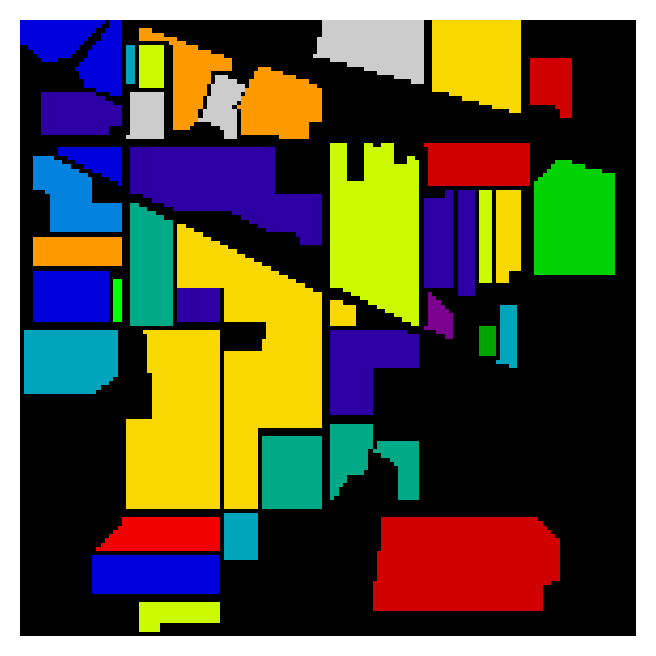

In [152]:
from matplotlib import colors
cmap = pl.get_cmap('nipy_spectral')
# Define discrete boundaries for the values (0 to 16)
bounds = np.arange(min_label, max_label+1, 1)  # Ensures correct mapping of colors
norm = BoundaryNorm(bounds, cmap.N)

fig, axes = pl.subplots(figsize=(5,4))
pl.imshow(labelsMat, cmap=cmap,norm=norm)
#pl.colorbar()
pl.axis('off')
#pl.title(r"Ground Truth")
pl.savefig("Images/GroundTruth.png", dpi = 600, bbox_inches = "tight")
pl.show()

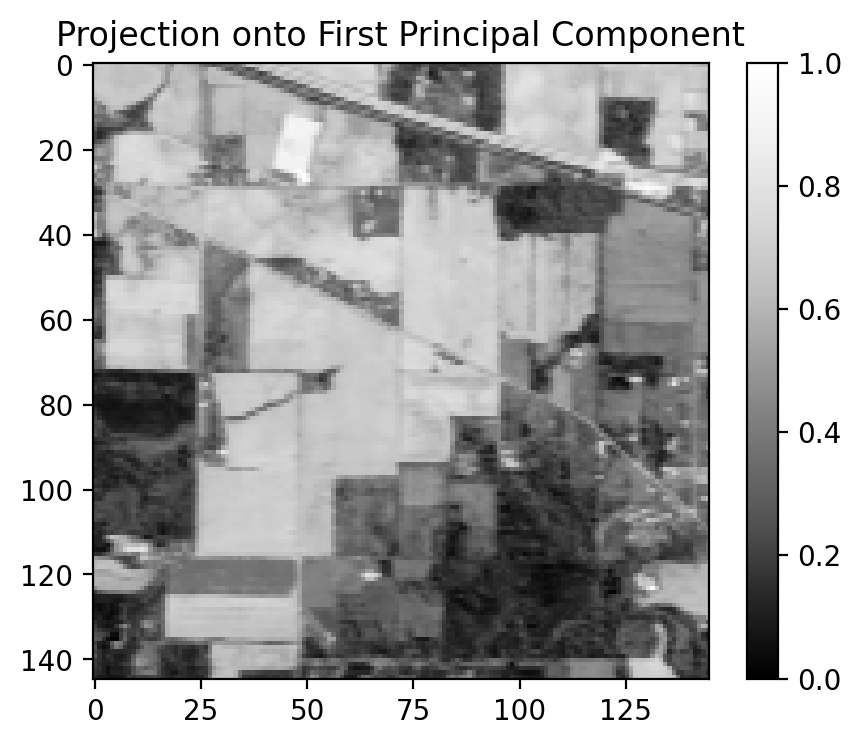

In [124]:
# Reshape into 2D image
img_pca = X_pca.reshape(nY,nX)

# Normalize to range [0,1] 
img_pca = (img_pca - np.min(img_pca))/(np.max(img_pca)-np.min(img_pca))

fig, axes = pl.subplots(figsize=(5,4))
pl.imshow(img_pca, cmap='Greys_r')
pl.colorbar()
pl.title('Projection onto First Principal Component')
pl.show()

### Preliminary Results


SuperPCA


In [233]:
S = 100
k = 15
T = 30
nComponents = 30
n_SVM_runs = 10
np.random.seed(1)
seeds = np.random.randint(low=0, high=1000, size=n_SVM_runs) # Use these seeds for all subsequent experiments 

In [234]:
# SuperPCA
predicted_labels_array_superpca = np.zeros((n_SVM_runs, data3Darr.shape[0], data3Darr.shape[1]))

superpca = SuperPCA()
superpca.initialize(data3Darr, labelsMat)
superpca.segment(S, method="SLIC", **{'sigma':0.0, 'compactness':0.2})
superpca.superpixelwiseDataMatFromGlobalDataMat()
superpca.reduceAndAssemble(nComponents)

Successfully segmented the image into 97 superpixels.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03797546488387731..1.0016150311814884].


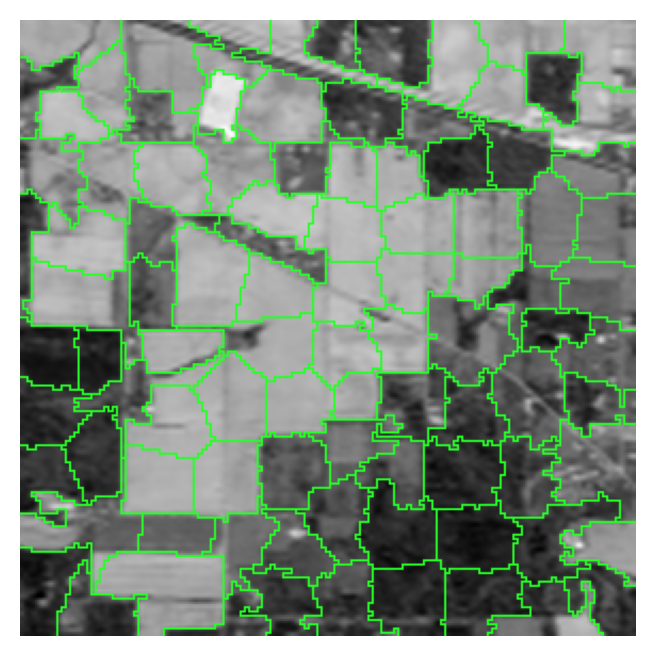

In [235]:
segments = superpca.segments
from skimage.segmentation import mark_boundaries

fig, ax = pl.subplots(figsize=(5,4))
pl.imshow(mark_boundaries(img_pca, segments,color=(0.15, 1.0, 0.15),mode='subpixel'),cmap='Greys_r')
ax.axis('off')
pl.savefig("Images/prelim_seg_img.png", dpi = 600, bbox_inches = "tight")
pl.show()

In [236]:
acc_array = np.zeros(n_SVM_runs)

for j in range(n_SVM_runs):
        superpca.performClassification(T, random_seed=seeds[j])
        predicted_labels_array_superpca[j] = superpca.labels2D_array_predicted
        acc_array[j] = superpca.overall_accuracy
        
acc_superpca = np.mean(acc_array)
print("Accuracy:", acc_superpca)
from scipy.stats import mode
predicted_labels_superpca, _ = mode(predicted_labels_array_superpca, axis=0, keepdims=False)

np.save('preliminary_results/prelim_acc_superpca.npy', acc_superpca)
np.save('preliminary_results/prelim_class_map_superpca.npy', predicted_labels_superpca)

Accuracy: 0.892019975540155


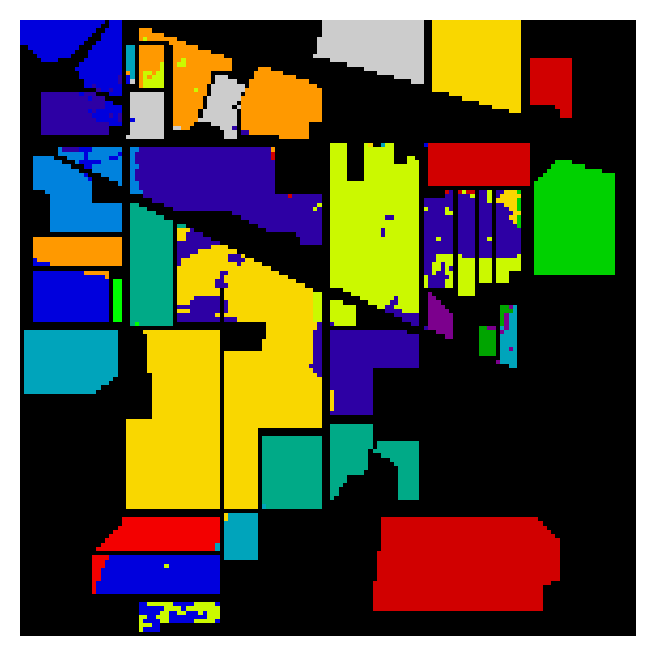

In [172]:
fig, ax = pl.subplots(figsize=(5,4))
pl.imshow(predicted_labels_superpca, cmap=cmap, norm=norm)
ax.axis('off')
pl.savefig("Images/prelim_superpca_class_map.png", dpi = 600, bbox_inches = "tight")
pl.show()

S3-PCA

In [227]:
# S3PCA
predicted_labels_array_s3pca = np.zeros((n_SVM_runs, data3Darr.shape[0], data3Darr.shape[1]))

s3pca = S3PCA()
s3pca.initialize(data3Darr, labelsMat)
s3pca.segment(S, method="SLIC", **{'sigma':0.0, 'compactness':0.2})
s3pca.superpixelwiseDataMatFromGlobalDataMat()
s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
s3pca.reduceAndAssemble(nComponents)

Successfully segmented the image into 322 superpixels.


In [179]:
acc_array = np.zeros(n_SVM_runs)

for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=seeds[j])
        predicted_labels_array_s3pca[j] = s3pca.labels2D_array_predicted
        acc_array[j] = s3pca.overall_accuracy
        
acc_s3pca = np.mean(acc_array)
print("Accuracy:", acc_s3pca)
from scipy.stats import mode
predicted_labels_s3pca, _ = mode(predicted_labels_array_s3pca, axis=0, keepdims=False)

np.save('preliminary_results/prelim_acc_s3pca.npy', acc_s3pca)
np.save('preliminary_results/prelim_class_map_s3pca.npy', predicted_labels_s3pca)

Accuracy: 0.9030778638401957


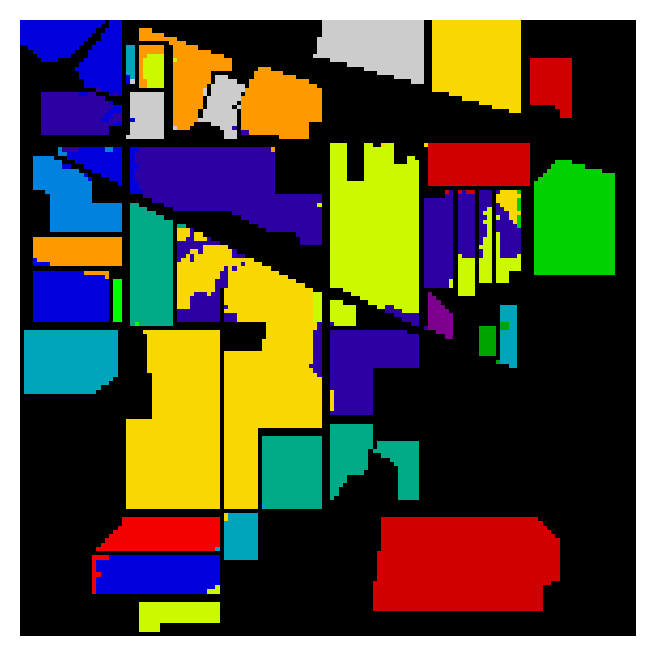

In [175]:
fig, ax = pl.subplots(figsize=(5,4))
pl.imshow(predicted_labels_s3pca, cmap=cmap, norm=norm)
ax.axis('off')
pl.savefig("Images/prelim_s3pca_class_map.png", dpi = 600, bbox_inches = "tight")
pl.show()

### Experiments

We perform experiments to evaluate the impact of the following on the classification accuracy. The dimensionality of the reduced feature set is fixed as 30 following the paper.

    1) S - Number of superpixels
    2) k - Number of neighbors to consider for reconstruction
    3) Reconstruction criterion (Spectral similarity vs Spatial proximity)
    4) Segmentation algorithm (SLIC vs ERS)
    5) T - Number of training samples per class

Experiment 1: Parameter tuning for SuperPCA.


Perform dimensionality reduction using SuperPCA with S = {1, 3, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300} using ERS for segmentation. For each case, perform SVM classification 10 times with randomized training dataset with T = {5, 10, 20, 30} samples per class and calculate the average overall accuracy.

In [ ]:
n_SVM_runs = 10
nComponents = 30
seeds = np.random.randint(low = 0, high = 1000, size = n_SVM_runs)
S_array = np.array([1, 3, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300])
T_array = np.array([5, 10, 20, 30])

In [200]:
acc_arrs_vs_S = np.zeros((len(S_array), len(T_array)))

for it, S in enumerate(S_array):
    print(f"\nPerforming iteration for S = {S}")
    
    spca = SuperPCA()
    spca.initialize(data3Darr, labelsMat)
    spca.segment(S, method = "ERS")
    spca.superpixelwiseDataMatFromGlobalDataMat()
    spca.reduceAndAssemble(nComponents)
    
    acc_vs_T = np.zeros(len(T_array))
    
    for T_it, T in enumerate(T_array):
        acc_array = np.zeros(n_SVM_runs)
        print(f"\nPerforming iteration for T = {T}")
        for j in range(n_SVM_runs):
            spca.performClassification(T, random_seed=seeds[j])
            acc_array[j] = spca.overall_accuracy
        
        acc_vs_T[T_it] = np.mean(acc_array)
    
    acc_arrs_vs_S[it,:] = acc_vs_T


Performing iteration for S = 1
Successfully segmented the image into 1 superpixels.

Performing iteration for T = 5

Performing iteration for T = 10

Performing iteration for T = 20

Performing iteration for T = 30

Performing iteration for S = 3
Successfully segmented the image into 3 superpixels.

Performing iteration for T = 5

Performing iteration for T = 10

Performing iteration for T = 20

Performing iteration for T = 30

Performing iteration for S = 5
Successfully segmented the image into 5 superpixels.

Performing iteration for T = 5

Performing iteration for T = 10

Performing iteration for T = 20

Performing iteration for T = 30

Performing iteration for S = 10
Successfully segmented the image into 10 superpixels.

Performing iteration for T = 5

Performing iteration for T = 10

Performing iteration for T = 20

Performing iteration for T = 30

Performing iteration for S = 20
Successfully segmented the image into 20 superpixels.

Performing iteration for T = 5

Performing ite

In [ ]:
import pandas as pd
df1 = pd.DataFrame(data=acc_arrs_vs_S, index=S_array, columns=T_array)
df1.index.name = 'Number of Superpixels (S)'
df1.columns.name = 'Training Samples (T)'
df1.to_csv('Experiments/Exp1.csv')

T =  5


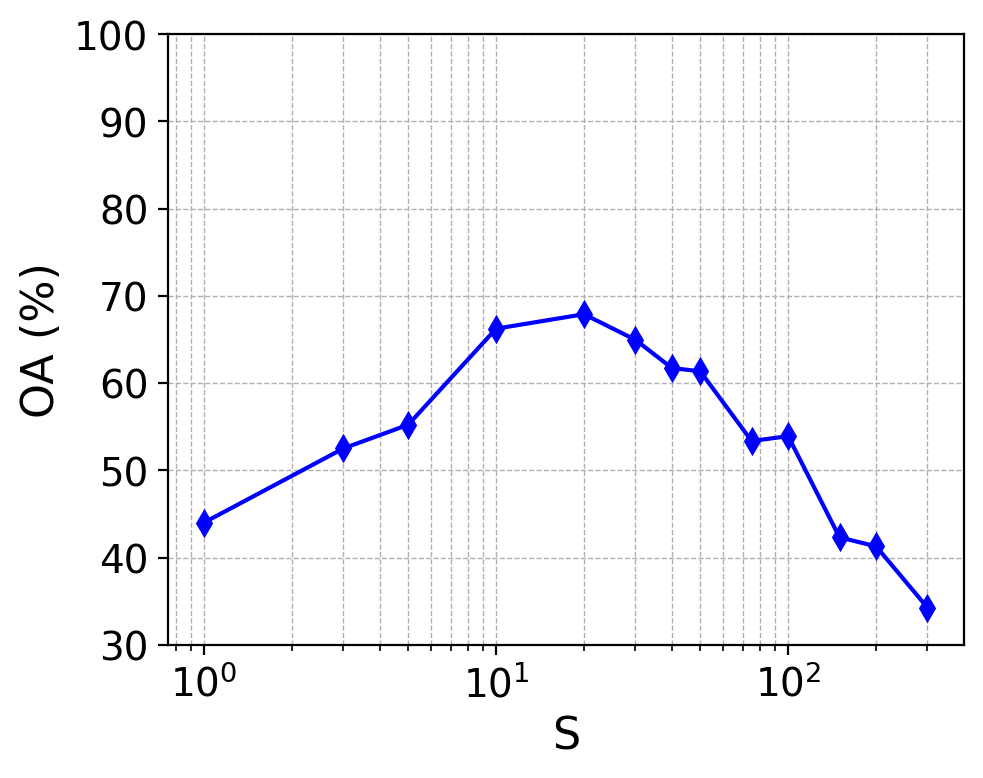

T =  10


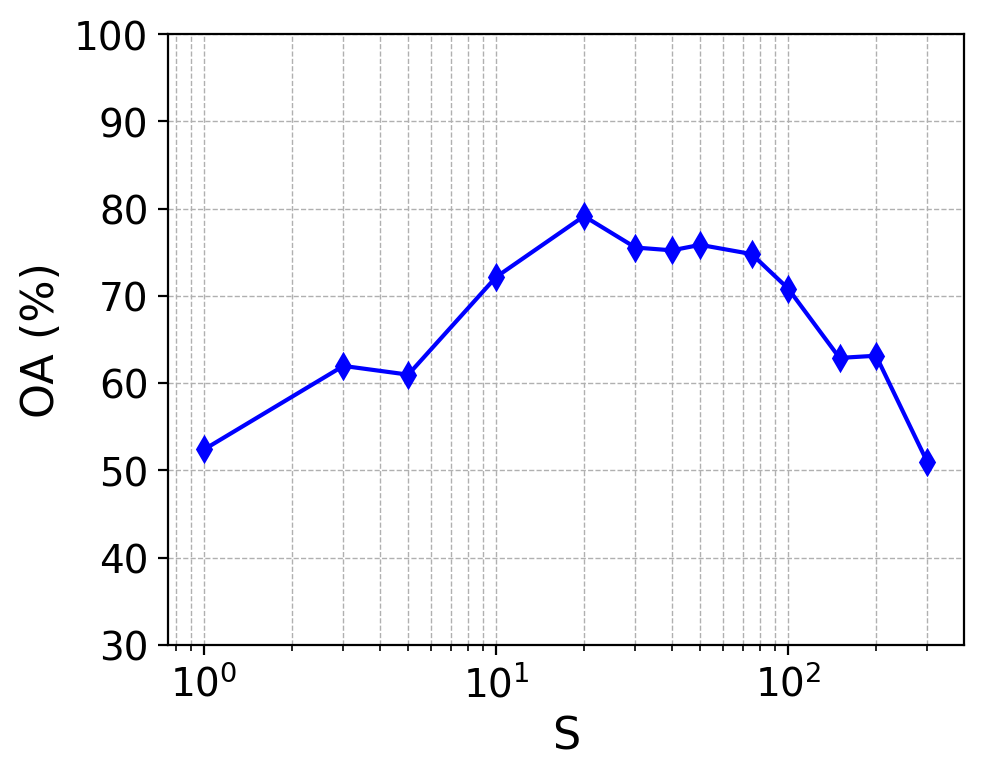

T =  20


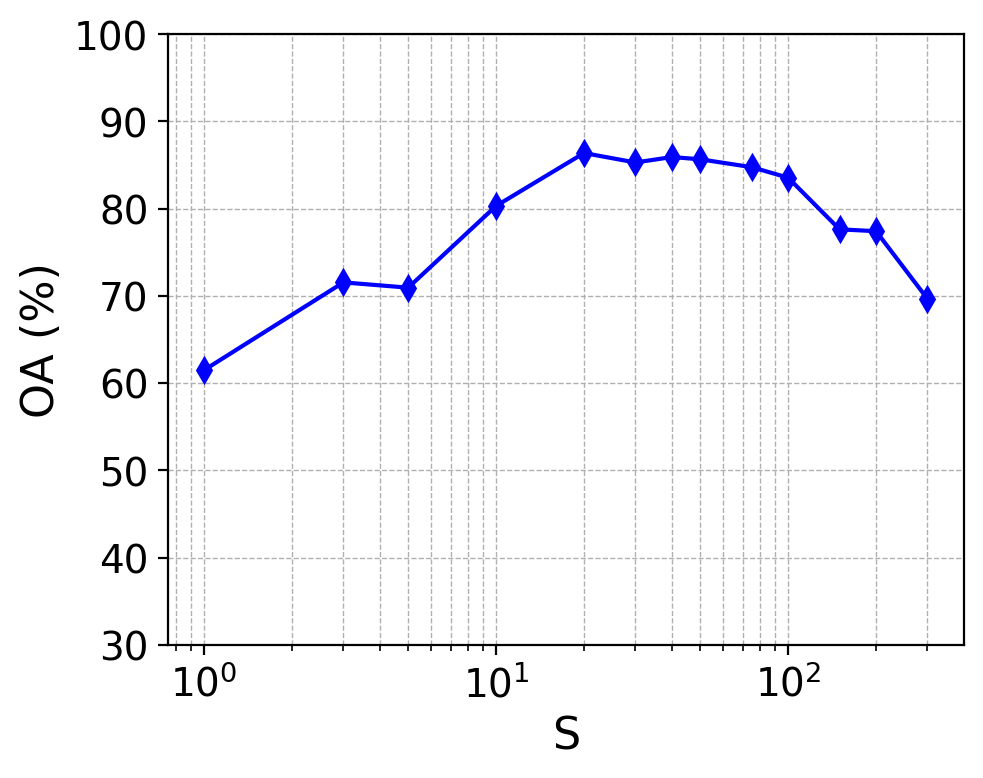

T =  30


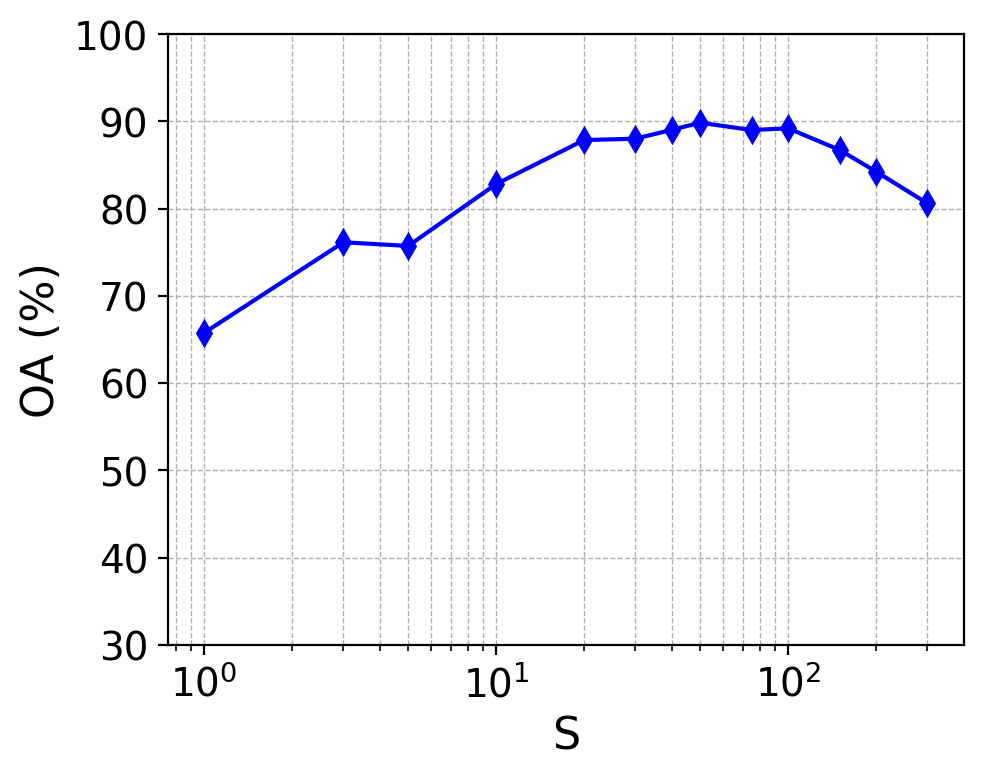

In [239]:
exp1 = pd.read_csv("Experiments/Exp1.csv",index_col=0)
acc_arrs_vs_S_from_csv = exp1.to_numpy()

for i, T in enumerate(T_array):
    print("T = ",T)
    pl.figure(figsize=(5, 4))
    pl.plot(S_array, acc_arrs_vs_S_from_csv[:, i]*100, marker='d', color='b')
    pl.xscale('log')
    pl.xticks(fontsize=14)
    pl.yticks(fontsize=14)
    pl.ylim([30, 100])
    pl.xlabel('S', fontsize=16)
    pl.ylabel('OA (%)', fontsize=16)
    pl.grid(True, which='both', linestyle='--', linewidth=0.5)
    pl.tight_layout()
    pl.savefig(f"Images/Exp1_T_{T:.0f}.png", dpi = 600)
    pl.show()

Experiment 2(a): Parameter tuning for S3-PCA.

Perform segmentation with S = 50 (optimal value for SuperPCA from experiment 1) using ERS and perform superpixelwise reconstruction using k = {1, 3, 5, 7, 9, 11, 13, 15, 17, 19} using spectral similarity as criterion. Reduce the dimensionality to 30, and then perform SVM classification 10 times with randomized training dataset with T = 30 samples per class and calculate the average overall accuracy.

In [ ]:
S = 50
k_array = np.array([0, 5, 7, 11, 13, 15, 17, 19])

T = 30
nComponents = 30
n_SVM_runs = 10
seeds = np.random.randint(low = 0, high = 1000, size = n_SVM_runs)
acc_vs_k = np.zeros(len(k_array))

In [211]:
s3pca = S3PCA()
s3pca.initialize(data3Darr, labelsMat)
s3pca.segment(S, method="ERS")
s3pca.superpixelwiseDataMatFromGlobalDataMat()

for it, k in enumerate(k_array):
    
    print(f"\nPerforming iteration for k = {k}")
    s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
    s3pca.reduceAndAssemble(nComponents)

    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=seeds[j])
        acc_array[j] = s3pca.overall_accuracy
        
    acc_vs_k[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")

Successfully segmented the image into 50 superpixels.

Performing iteration for k = 0
Accuracy : 0.8990725642070932

Performing iteration for k = 5
Accuracy : 0.9069812474520994

Performing iteration for k = 7
Accuracy : 0.9084284549531187

Performing iteration for k = 11
Accuracy : 0.90902975947819

Performing iteration for k = 13
Accuracy : 0.916449245821443

Performing iteration for k = 15
Accuracy : 0.916041581736649

Performing iteration for k = 17
Accuracy : 0.9155218100285365

Performing iteration for k = 19
Accuracy : 0.9143701589889931


In [ ]:
df2a = pd.DataFrame(acc_vs_k, index=k_array, columns=["Overall Accuracy"])
df2a.to_csv('Experiments/Exp2a.csv')

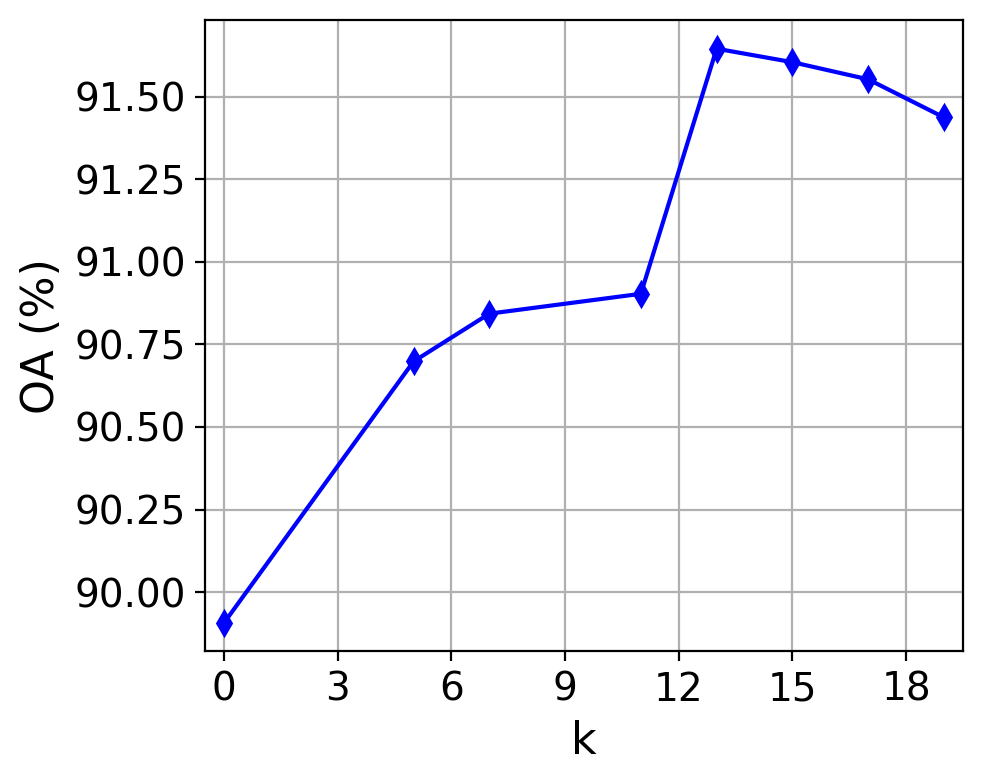

In [298]:
exp2a = pd.read_csv('Experiments/Exp2a.csv', index_col=0)
pl.figure(figsize=(5, 4))
pl.plot(exp2a.index, exp2a['Overall Accuracy']*100, marker='d', linestyle='-', color='b')
pl.xlabel('k', fontsize=16)
pl.ylabel('OA (%)', fontsize=16)
pl.xticks([0,3,6,9,12,15,18],fontsize=14)
pl.xlim([-0.5, 19.5])
pl.yticks(fontsize=14)
pl.grid(True)
pl.tight_layout()
pl.savefig("Images/Exp2a.png", dpi = 600)
pl.show()

Experiment 2(b): Parameter tuning for S3-PCA.

Perform dimensionality reduction using S3-PCA with S = {1, 3, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300} and k = 13 (optimal value found in Exp 2(a)) using ERS for segmentation. For each case, perform SVM classification 10 times with randomized training dataset with T = 30 samples per class and calculate the average overall accuracy.

In [ ]:
k = 13
n_SVM_runs = 10
nComponents = 30
seeds = np.random.randint(low = 0, high = 1000, size = n_SVM_runs)
S_array = np.array([1, 3, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300])
acc_vs_S = np.zeros(len(S_array))

In [243]:
for it, S in enumerate(S_array):
    
    print(f"\nPerforming iteration for S = {S}")
    
    s3pca = S3PCA()
    s3pca.initialize(data3Darr, labelsMat)
    s3pca.segment(S, method="ERS")
    
    s3pca.superpixelwiseDataMatFromGlobalDataMat()
    s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
    s3pca.reduceAndAssemble(nComponents)
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=seeds[j])
        acc_array[j] = s3pca.overall_accuracy
        
    acc_vs_S[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")


Performing iteration for S = 1
Successfully segmented the image into 1 superpixels.
Accuracy : 0.8067876070118223

Performing iteration for S = 3
Successfully segmented the image into 3 superpixels.
Accuracy : 0.8617305340399511

Performing iteration for S = 5
Successfully segmented the image into 5 superpixels.
Accuracy : 0.846881369751325

Performing iteration for S = 10
Successfully segmented the image into 10 superpixels.
Accuracy : 0.8884732980024459

Performing iteration for S = 20
Successfully segmented the image into 20 superpixels.
Accuracy : 0.9131777415409703

Performing iteration for S = 30
Successfully segmented the image into 30 superpixels.
Accuracy : 0.9087647778230737

Performing iteration for S = 40
Successfully segmented the image into 40 superpixels.
Accuracy : 0.9129535262943334

Performing iteration for S = 50
Successfully segmented the image into 50 superpixels.
Accuracy : 0.916449245821443

Performing iteration for S = 75
Successfully segmented the image into 7

In [251]:
df2b = pd.DataFrame(acc_vs_S, index=S_array, columns=["Overall Accuracy"])
df2b.to_csv('Experiments/Exp2b.csv')

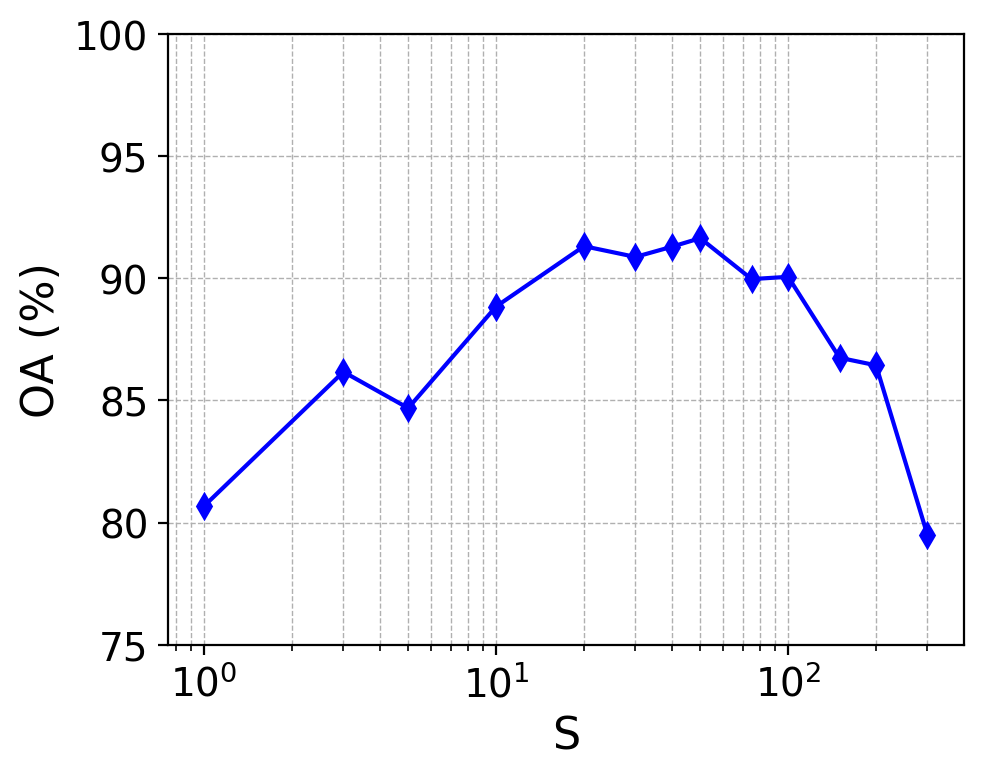

In [256]:
exp2b = pd.read_csv('Experiments/Exp2b.csv', index_col=0)

pl.figure(figsize=(5, 4))
pl.plot(exp2b.index, exp2b["Overall Accuracy"]*100, marker='d', linestyle='-', color='blue')
pl.xscale('log')  
pl.xlabel('S', fontsize=16)
pl.ylabel('OA (%)', fontsize=16)
pl.xticks(fontsize=14)
pl.yticks(fontsize=14)
pl.ylim([75, 100])
pl.grid(True, which='both', linestyle='--', linewidth=0.5)
pl.tight_layout()
pl.savefig("Images/Exp2b.png", dpi = 600)
pl.show()


Experiment 3: Comparison between different methods.

Set S = 50, k = 13. Perform classification tests for the following cases : 1) Raw data 2) PCA 3) SuperPCA 4) S3-PCA. For each case, perform SVM classification 10 times with randomized training dataset with T = {5, 10, 20, 30, 40, 50, 60} samples per class and calculate the average overall accuracy.

In [ ]:
k = 13
S = 50
method = ["Raw", "PCA", "SuperPCA", "S3-PCA"]
T_array = np.array([5, 10, 20, 30, 40, 50, 60])
n_SVM_runs = 10
seeds = np.random.randint(low = 0, high = 1000, size = n_SVM_runs)
acc_arr_vs_method = np.zeros((len(method), len(T_array)))

In [261]:
# Raw data
acc_raw = np.zeros(len(T_array),dtype=float)

raw = RawData()
raw.initialize(data3Darr, labelsMat)

for it, T in enumerate(T_array):
    
    print(f"\nPerforming iteration for T = {T}")
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        raw.performClassification(T, random_seed=seeds[j])
        acc_array[j] = raw.overall_accuracy
        
    acc_raw[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")

acc_arr_vs_method[0,:] = acc_raw


Performing iteration for T = 5
Accuracy : 0.44092831153505757

Performing iteration for T = 10
Accuracy : 0.5374665477252453

Performing iteration for T = 20
Accuracy : 0.6237807943690296

Performing iteration for T = 30
Accuracy : 0.6691805951895637

Performing iteration for T = 40
Accuracy : 0.7091096880809751

Performing iteration for T = 50
Accuracy : 0.7291335286730849

Performing iteration for T = 60
Accuracy : 0.7468524798643494


In [262]:
# PCA
acc_pca = np.zeros(len(T_array),dtype=float)
pca_ = PCA()
pca_.initialize(data3Darr, labelsMat)
pca_.reduceAndAssemble(nComponents)

for it, T in enumerate(T_array):
    
    print(f"\nPerforming iteration for T = {T}")
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        pca_.performClassification(T, random_seed=seeds[j])
        acc_array[j] = pca_.overall_accuracy
        
    acc_pca[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")

acc_arr_vs_method[1,:] = acc_pca


Performing iteration for T = 5
Accuracy : 0.43925656406726327

Performing iteration for T = 10


c:\Users\shubh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shubh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shubh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Accuracy : 0.524323520666072

Performing iteration for T = 20
Accuracy : 0.6132730015082956

Performing iteration for T = 30
Accuracy : 0.6557072971871178

Performing iteration for T = 40
Accuracy : 0.691055567031605

Performing iteration for T = 50
Accuracy : 0.711772708246128

Performing iteration for T = 60
Accuracy : 0.7265684612123782


In [263]:
# SuperPCA
acc_superpca = np.zeros(len(T_array))
superpca = SuperPCA()
superpca.initialize(data3Darr, labelsMat)
superpca.segment(S, method="ERS")
superpca.superpixelwiseDataMatFromGlobalDataMat()
superpca.reduceAndAssemble(nComponents)

for it, T in enumerate(T_array):
    
    print(f"\nPerforming iteration for T = {T}")
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        superpca.performClassification(T, random_seed=seeds[j])
        acc_array[j] = superpca.overall_accuracy
        
    acc_superpca[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")
    
acc_arr_vs_method[2,:] = acc_superpca

Successfully segmented the image into 50 superpixels.

Performing iteration for T = 5
Accuracy : 0.613472317828695

Performing iteration for T = 10
Accuracy : 0.7584002378828428

Performing iteration for T = 20
Accuracy : 0.8564705882352941

Performing iteration for T = 30
Accuracy : 0.8984406848756624

Performing iteration for T = 40
Accuracy : 0.9138194587895064

Performing iteration for T = 50
Accuracy : 0.9226768522394307

Performing iteration for T = 60
Accuracy : 0.9272679101314116


In [264]:
acc_s3pca = np.zeros(len(T_array))
s3pca.initialize(data3Darr, labelsMat)
s3pca.segment(S, method="ERS")
s3pca.superpixelwiseDataMatFromGlobalDataMat()
s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
s3pca.reduceAndAssemble(nComponents)

for it, T in enumerate(T_array):
    
    print(f"\nPerforming iteration for T = {T}")
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=seeds[j])
        acc_array[j] = s3pca.overall_accuracy
        
    acc_s3pca[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")

acc_arr_vs_method[3,:] = acc_s3pca

Successfully segmented the image into 50 superpixels.

Performing iteration for T = 5
Accuracy : 0.6300422853771266

Performing iteration for T = 10
Accuracy : 0.7747249479631282

Performing iteration for T = 20
Accuracy : 0.8754348919054802

Performing iteration for T = 30
Accuracy : 0.916449245821443

Performing iteration for T = 40
Accuracy : 0.9357054327618262

Performing iteration for T = 50
Accuracy : 0.9410318124738385

Performing iteration for T = 60
Accuracy : 0.95


In [265]:
df3 = pd.DataFrame(data=acc_arr_vs_method, index=method, columns=T_array)
df3.index.name = "Method"
df3.columns.name = "Training Samples (T)"

# Save to CSV
df3.to_csv("Experiments/Exp3.csv")

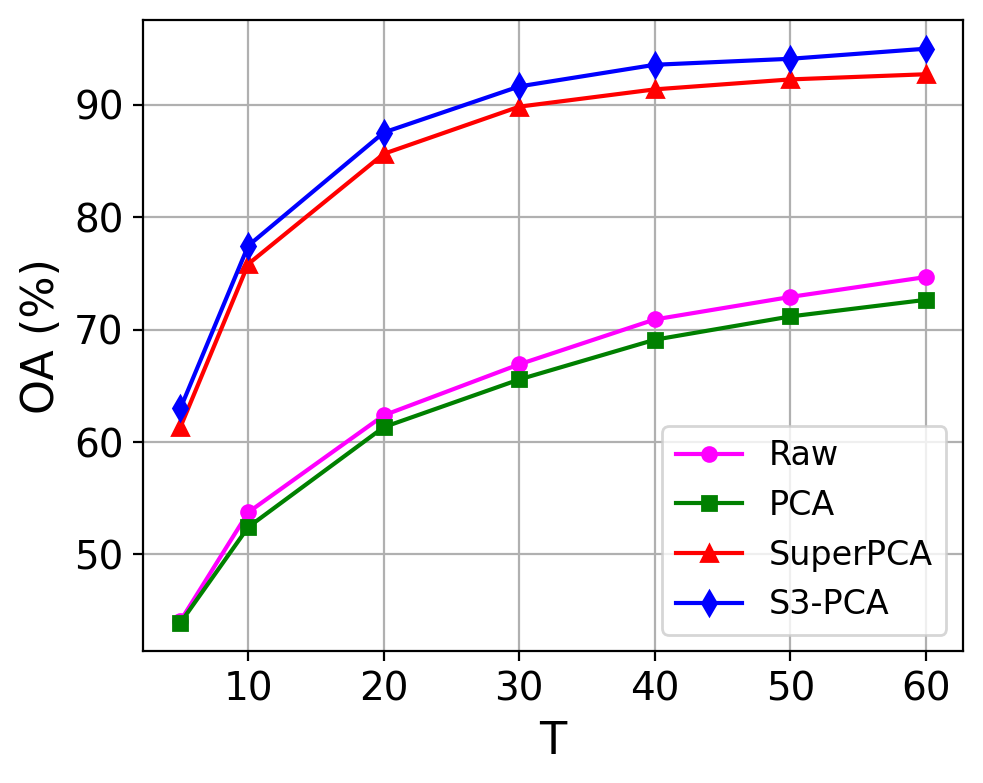

In [276]:
exp3 = pd.read_csv("Experiments/Exp3.csv", index_col=0)
pl.figure(figsize=(5, 4))
colors = ['magenta', 'green', 'red', 'blue']
markers = ['.','s','^','d']
sizes = [10,5,6,6]
for i,method in enumerate(exp3.index):
    pl.plot(exp3.columns.astype(int), exp3.loc[method]*100, color = colors[i], label=method, marker=markers[i], markersize=sizes[i])

pl.xlabel("T",fontsize=16)
pl.ylabel("OA (%)",fontsize=16)
pl.grid(True)
pl.xticks(fontsize=14)
pl.yticks(fontsize=14)
pl.legend(fontsize=12)
pl.tight_layout()
pl.savefig("Images/Exp3.png",dpi=600)
pl.show()

Classification Maps

In [ ]:
k = 13
S = 50 
T = 30
n_SVM_runs = 10
seeds = np.random.randint(low = 0, high = 1000, size = n_SVM_runs)

Raw Data

In [281]:
predicted_labels_array_raw = np.zeros((n_SVM_runs, data3Darr.shape[0], data3Darr.shape[1]))
acc_array = np.zeros(n_SVM_runs)

raw = RawData()
raw.initialize(data3Darr, labelsMat)

for j in range(n_SVM_runs):
        raw.performClassification(T, random_seed=seeds[j])
        predicted_labels_array_raw[j] = raw.labels2D_array_predicted
        acc_array[j] = raw.overall_accuracy

acc_raw = np.mean(acc_array)
print("Accuracy:", acc_raw)    
predicted_labels_raw, _ = mode(predicted_labels_array_raw, axis=0, keepdims=False)

np.save('Experiments/exp3_acc_raw.npy', acc_raw)
np.save('Experiments/exp3_class_map_raw.npy', predicted_labels_raw)

Accuracy: 0.6691805951895637


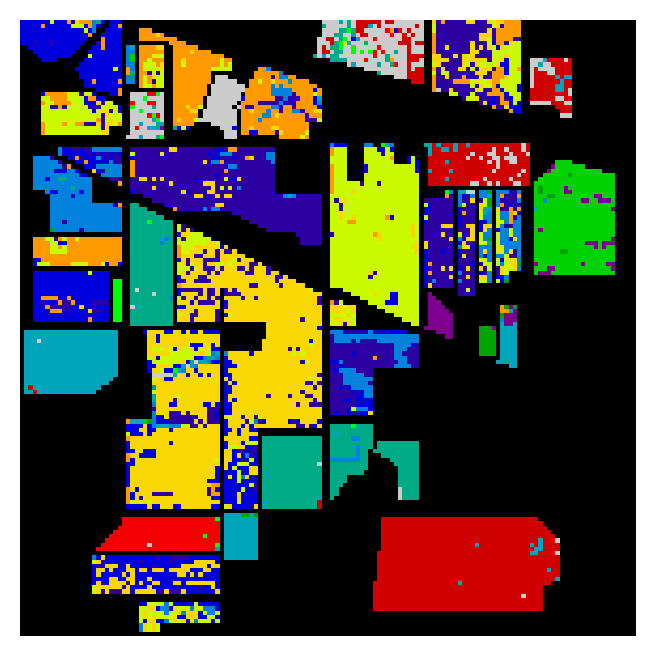

In [279]:
fig, ax = pl.subplots(figsize=(5,4))
pl.imshow(predicted_labels_raw, cmap=cmap, norm=norm)
ax.axis('off')
pl.savefig("Images/exp3_raw_class_map.png", dpi = 600, bbox_inches = "tight")
pl.show()

PCA

In [280]:
predicted_labels_array_pca = np.zeros((n_SVM_runs, data3Darr.shape[0], data3Darr.shape[1]))
acc_array = np.zeros(n_SVM_runs)

pca_ = PCA()
pca_.initialize(data3Darr, labelsMat)
pca_.reduceAndAssemble(nComponents)

for j in range(n_SVM_runs):
        pca_.performClassification(T, random_seed=seeds[j])
        predicted_labels_array_pca[j] = pca_.labels2D_array_predicted
        acc_array[j] = pca_.overall_accuracy

acc_pca = np.mean(acc_array)
print("Accuracy:", acc_pca)    
predicted_labels_pca, _ = mode(predicted_labels_array_pca, axis=0, keepdims=False)

np.save('Experiments/exp3_acc_pca.npy', acc_pca)
np.save('Experiments/exp3_class_map_pca.npy', predicted_labels_pca)

Accuracy: 0.6557072971871178


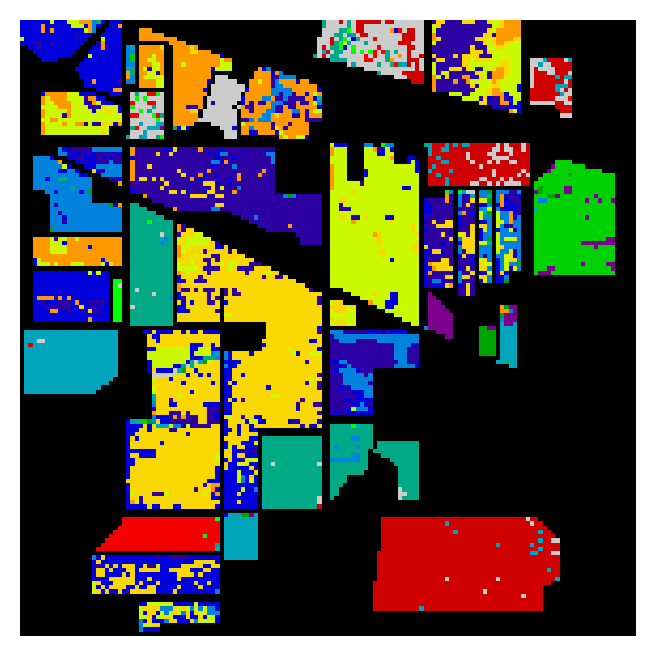

In [282]:
fig, ax = pl.subplots(figsize=(5,4))
pl.imshow(predicted_labels_pca, cmap=cmap, norm=norm)
ax.axis('off')
pl.savefig("Images/exp3_pca_class_map.png", dpi = 600, bbox_inches = "tight")
pl.show()

SuperPCA

In [283]:
acc_array = np.zeros(n_SVM_runs)
predicted_labels_array_superpca = np.zeros((n_SVM_runs, data3Darr.shape[0], data3Darr.shape[1]))

superpca = SuperPCA()
superpca.initialize(data3Darr, labelsMat)
superpca.segment(S, method="ERS")
superpca.superpixelwiseDataMatFromGlobalDataMat()
superpca.reduceAndAssemble(nComponents)

for j in range(n_SVM_runs):
        superpca.performClassification(T, random_seed=seeds[j])
        predicted_labels_array_superpca[j] = superpca.labels2D_array_predicted
        acc_array[j] = superpca.overall_accuracy
        
acc_superpca = np.mean(acc_array)
print("Accuracy:", acc_superpca)
from scipy.stats import mode
predicted_labels_superpca, _ = mode(predicted_labels_array_superpca, axis=0, keepdims=False)

np.save('Experiments/exp3_acc_superpca.npy', acc_superpca)
np.save('Experiments/exp3_class_map_superpca.npy', predicted_labels_superpca)

Successfully segmented the image into 50 superpixels.
Accuracy: 0.8984406848756624


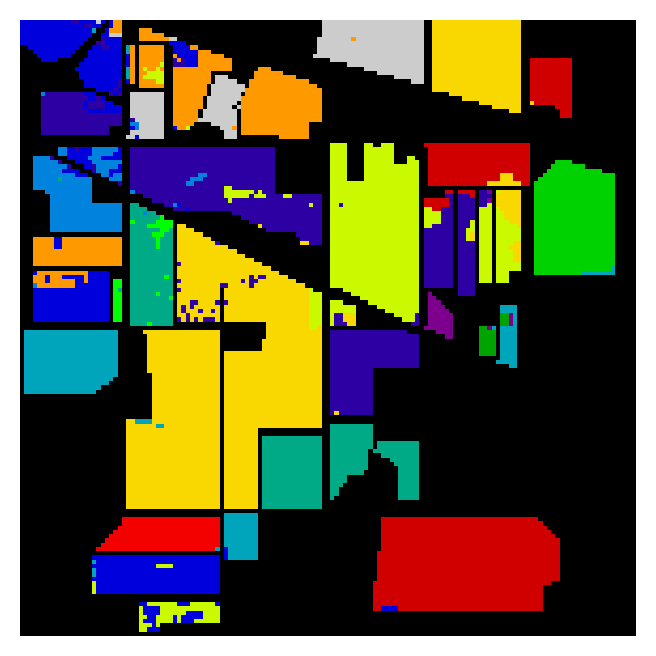

In [284]:
fig, ax = pl.subplots(figsize=(5,4))
pl.imshow(predicted_labels_superpca, cmap=cmap, norm=norm)
ax.axis('off')
pl.savefig("Images/exp3_superpca_class_map.png", dpi = 600, bbox_inches = "tight")
pl.show()

S3PCA

In [285]:
predicted_labels_array_s3pca = np.zeros((n_SVM_runs, data3Darr.shape[0], data3Darr.shape[1]))

s3pca = S3PCA()
s3pca.initialize(data3Darr, labelsMat)
s3pca.segment(S, method="ERS")
s3pca.superpixelwiseDataMatFromGlobalDataMat()
s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
s3pca.reduceAndAssemble(nComponents)

for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=seeds[j])
        predicted_labels_array_s3pca[j] = s3pca.labels2D_array_predicted
        acc_array[j] = s3pca.overall_accuracy
        
acc_s3pca = np.mean(acc_array)
print("Accuracy:", acc_s3pca)
from scipy.stats import mode
predicted_labels_s3pca, _ = mode(predicted_labels_array_s3pca, axis=0, keepdims=False)

np.save('Experiments/exp3_acc_s3pca.npy', acc_s3pca)
np.save('Experiments/exp3_class_map_s3pca.npy', predicted_labels_s3pca)

Successfully segmented the image into 50 superpixels.
Accuracy: 0.916449245821443


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03797546488387731..1.0016150311814884].


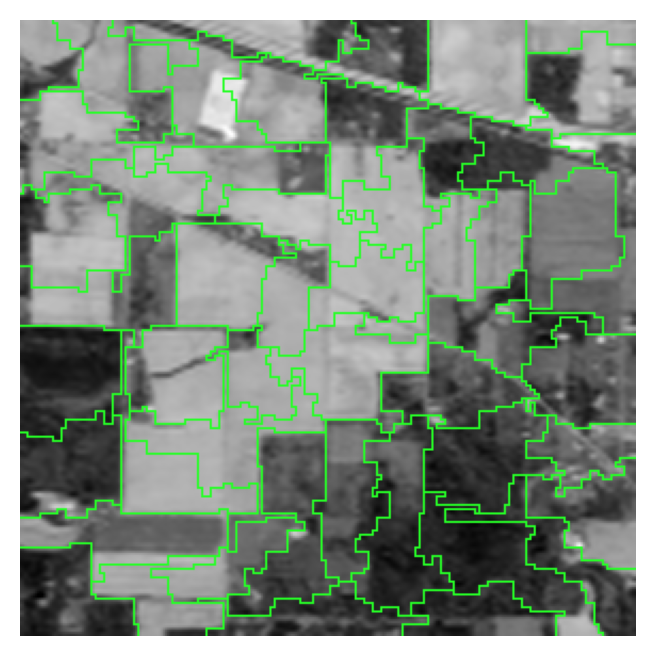

In [287]:
segments = s3pca.segments
from skimage.segmentation import mark_boundaries

fig, ax = pl.subplots(figsize=(5,4))
pl.imshow(mark_boundaries(img_pca, segments,color=(0.15, 1.0, 0.15),mode='subpixel'),cmap='Greys_r')
ax.axis('off')
pl.savefig("Images/exp3_seg_img.png", dpi = 600, bbox_inches = "tight")
pl.show()

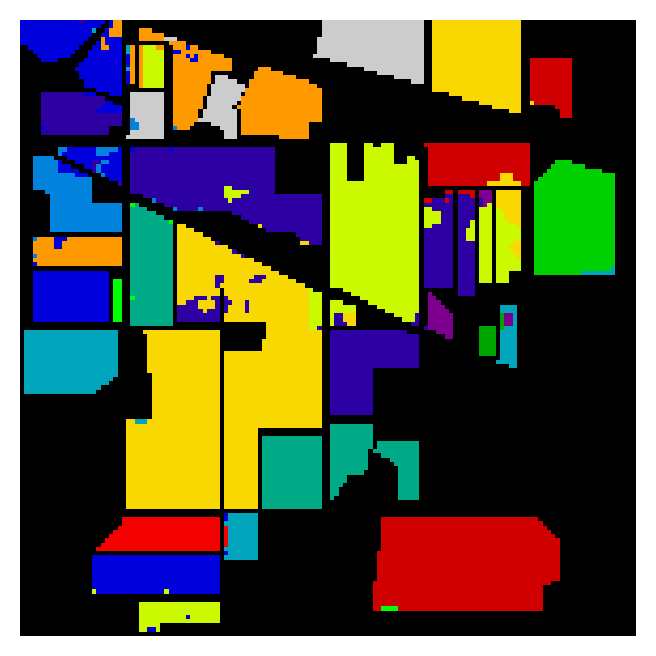

In [286]:
fig, ax = pl.subplots(figsize=(5,4))
pl.imshow(predicted_labels_s3pca, cmap=cmap, norm=norm)
ax.axis('off')
pl.savefig("Images/exp3_s3pca_class_map.png", dpi = 600, bbox_inches = "tight")
pl.show()

Experiment 4: Comparison between different image segmentation techniques.

Perform SuperPCA with S = {1, 3, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300} using 1) SLIC on first principal projection 2) ERS on first principal projection (already done in Exp1) 3) ERS on full HSI. For each case, perform SVM classification 10 times with randomized training dataset with T = 30 samples per class and calculate the average overall accuracy.

In [ ]:
T = 30
nComponents = 30
S_array = np.array([1, 3, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300])
n_SVM_runs = 10
seeds = np.random.randint(low = 0, high = 1000, size = n_SVM_runs)
seg_methods = ["ERS (pca)", "ERS (HSI)", "SLIC"]

acc_arr_vs_seg_method = np.zeros((len(seg_methods), len(S_array)))

In [296]:
# ERS (pca) has already been performed in exp 1. Read from saved file.
exp1 = pd.read_csv("Experiments/Exp1.csv", index_col = 0)
acc_ers_pca = exp1["30"].to_numpy()
acc_arr_vs_seg_method[0,:] = acc_ers_pca

In [297]:
# ERS (HSI)
acc_ers_hsi = np.zeros(len(S_array))

for it, S in enumerate(S_array):
    print(f"\nPerforming iteration for S = {S}")
    
    spca = SuperPCA()
    spca.initialize(data3Darr, labelsMat)
    spca.segment(S, method = "ERS", use_pca=False)
    spca.superpixelwiseDataMatFromGlobalDataMat()
    spca.reduceAndAssemble(nComponents)
    
    acc_array = np.zeros(n_SVM_runs)
    for j in range(n_SVM_runs):
        spca.performClassification(T, random_seed=seeds[j])
        acc_array[j] = spca.overall_accuracy
        
    acc_ers_hsi[it] = np.mean(acc_array)
    print(f"Accuracy : {np.mean(acc_array)}")
    
acc_arr_vs_seg_method[1,:] = acc_ers_hsi


Performing iteration for S = 1
Successfully segmented the image into 1 superpixels.
Accuracy : 0.6575417855686914

Performing iteration for S = 3
Successfully segmented the image into 3 superpixels.
Accuracy : 0.7239706481858948

Performing iteration for S = 5
Successfully segmented the image into 5 superpixels.
Accuracy : 0.8034345699143906

Performing iteration for S = 10
Successfully segmented the image into 10 superpixels.
Accuracy : 0.8625356706074194

Performing iteration for S = 20
Successfully segmented the image into 20 superpixels.
Accuracy : 0.874031797798614

Performing iteration for S = 30
Successfully segmented the image into 30 superpixels.
Accuracy : 0.9049531186302486

Performing iteration for S = 40
Successfully segmented the image into 40 superpixels.
Accuracy : 0.9225132490827559

Performing iteration for S = 50
Successfully segmented the image into 50 superpixels.
Accuracy : 0.9107725234406849

Performing iteration for S = 75
Successfully segmented the image into 

In [299]:
# SLIC (pca)
acc_slic_pca = np.zeros(len(S_array))
S_actual_SLIC = np.zeros(len(S_array))

for it, S in enumerate(S_array):
    print(f"\nPerforming iteration for S = {S}")
    
    spca = SuperPCA()
    spca.initialize(data3Darr, labelsMat)
    spca.segment(S, method = "SLIC", **{'sigma':0.0, 'compactness':0.2})
    S_actual_SLIC[it] = spca.nSegments
    spca.superpixelwiseDataMatFromGlobalDataMat()
    spca.reduceAndAssemble(nComponents)
    
    acc_array = np.zeros(n_SVM_runs)
    for j in range(n_SVM_runs):
        spca.performClassification(T, random_seed=seeds[j])
        acc_array[j] = spca.overall_accuracy
        
    acc_slic_pca[it] = np.mean(acc_array)
    print(f"Accuracy : {np.mean(acc_array)}")
    
acc_arr_vs_seg_method[2,:] = acc_slic_pca


Performing iteration for S = 1
Successfully segmented the image into 1 superpixels.
Accuracy : 0.6575417855686914

Performing iteration for S = 3
Successfully segmented the image into 4 superpixels.
Accuracy : 0.7102323685283326

Performing iteration for S = 5
Successfully segmented the image into 4 superpixels.
Accuracy : 0.7436200570729719

Performing iteration for S = 10
Successfully segmented the image into 6 superpixels.
Accuracy : 0.7948736241337139

Performing iteration for S = 20
Successfully segmented the image into 20 superpixels.
Accuracy : 0.8792397064818589

Performing iteration for S = 30
Successfully segmented the image into 34 superpixels.
Accuracy : 0.8923766816143498

Performing iteration for S = 40
Successfully segmented the image into 34 superpixels.
Accuracy : 0.9031899714635141

Performing iteration for S = 50
Successfully segmented the image into 43 superpixels.
Accuracy : 0.8938850387280881

Performing iteration for S = 75
Successfully segmented the image into 

In [300]:
df4 = pd.DataFrame(data=acc_arr_vs_seg_method, index = seg_methods, columns = S_array)
df4.index.name = "Segmentation Method"
df4.columns.name = "S"

df4.to_csv("Experiments/Exp4.csv")

np.save("Experiments/exp4_S_actual_SLIC.npy", S_actual_SLIC)

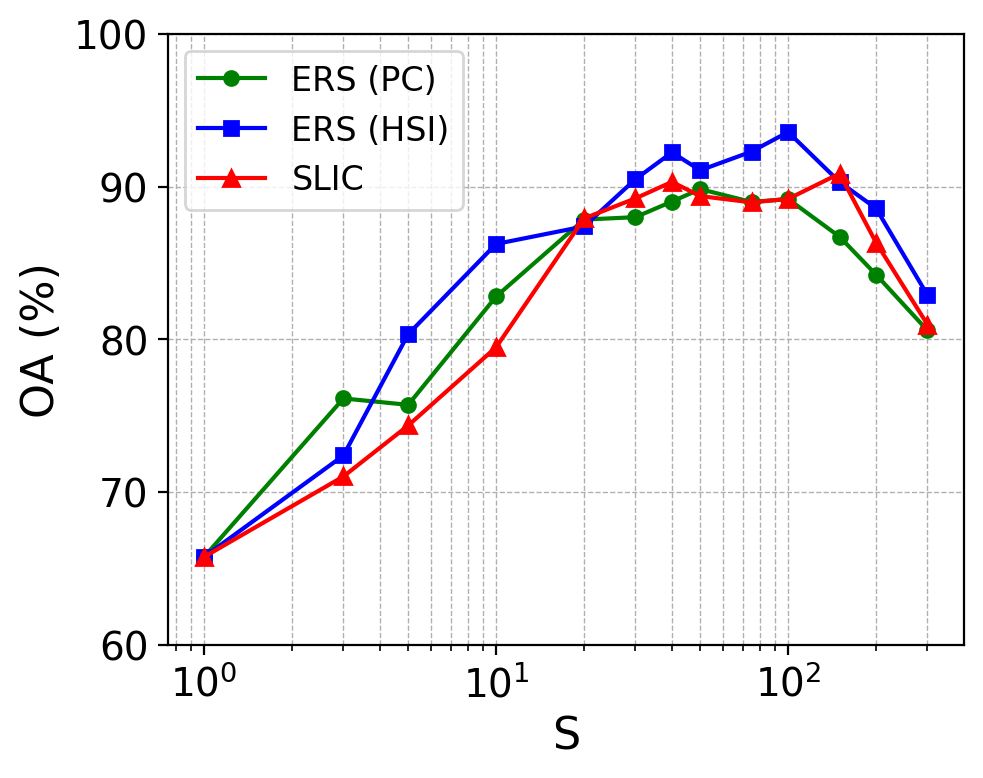

In [309]:
exp4 = pd.read_csv('Experiments/Exp4.csv', index_col=0)
S_SLIC = np.load("Experiments/exp4_S_actual_SLIC.npy")

pl.figure(figsize=(5, 4))
colors = ['green', 'blue', 'red', ]
fig_labels = ["ERS (PC)", "ERS (HSI)", "SLIC"]
markers = ['.','s','^','d']
sizes = [10,5,6,6]
for i,method in enumerate(exp4.index):
    pl.plot(exp4.columns.astype(int), exp4.loc[method]*100, color = colors[i], label=fig_labels[i], marker=markers[i], markersize=sizes[i])

pl.xlabel("S",fontsize=16)
pl.ylabel("OA (%)",fontsize=16)
pl.xscale("log")
pl.grid(True, which='both', linestyle='--', linewidth=0.5)
pl.xticks(fontsize=14)
pl.yticks([60, 70, 80, 90, 100],fontsize=14)
pl.ylim([60, 100])
pl.legend(fontsize=12)
pl.tight_layout()
pl.savefig("Images/Exp4.png",dpi=600)
pl.show()


Experiment 5: Effect of reconstruction criterion.

Perform S3-PCA with S = 100 (optimal values from previous experiment) using ERS on full HSI for k = {5, 7, 9, 11, 13, 15, 17, 19}. Use two different reconstruction criteria - 1) Spectral similarity 2) Spatial proximity. For each case, perform SVM classification 10 times with randomized training dataset with T = 30 samples per class and calculate the average overall accuracy.

In [345]:
S = 100
k_array = np.array([0, 5, 7, 9, 11, 13, 15, 17, 19])
n_SVM_runs = 20
seeds = np.random.randint(low = 0, high = 1000, size = n_SVM_runs)
nComponents = 30
T = 30

recon_method = ["Spectral", "Spatial", "Combined"]
acc_arr_vs_recon_method = np.zeros((len(recon_method), len(k_array)))

In [346]:
# Spectral
acc_spectral = np.zeros(len(k_array))
s3pca = S3PCA()
s3pca.initialize(data3Darr, labelsMat)
s3pca.segment(S, method="ERS", use_pca=False)
s3pca.superpixelwiseDataMatFromGlobalDataMat()

for it, k in enumerate(k_array):
    
    print(f"\nPerforming iteration for k = {k}")
    s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
    s3pca.reduceAndAssemble(nComponents)

    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=seeds[j])
        acc_array[j] = s3pca.overall_accuracy
        
    acc_spectral[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")

acc_arr_vs_recon_method[0,:] = acc_spectral

Successfully segmented the image into 100 superpixels.

Performing iteration for k = 0
Accuracy : 0.9316958825927436

Performing iteration for k = 5
Accuracy : 0.9359457806767224

Performing iteration for k = 7
Accuracy : 0.9378821850794946

Performing iteration for k = 9
Accuracy : 0.9379637178964533

Performing iteration for k = 11
Accuracy : 0.9386108846310639

Performing iteration for k = 13
Accuracy : 0.9376834488381572

Performing iteration for k = 15
Accuracy : 0.938116591928251

Performing iteration for k = 17
Accuracy : 0.9385803098247045

Performing iteration for k = 19
Accuracy : 0.9432327761924174


In [347]:
# Spatial
acc_spatial = np.zeros(len(k_array))
s3pca = S3PCA()
s3pca.initialize(data3Darr, labelsMat)
s3pca.segment(S, method="ERS", use_pca=False)
s3pca.superpixelwiseDataMatFromGlobalDataMat()

for it, k in enumerate(k_array):
    
    print(f"\nPerforming iteration for k = {k}")
    s3pca.reconstructSuperpixelwiseDataMat(k, "spatial")
    s3pca.reduceAndAssemble(nComponents)

    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=seeds[j])
        acc_array[j] = s3pca.overall_accuracy
        
    acc_spatial[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")

acc_arr_vs_recon_method[1,:] = acc_spatial

Successfully segmented the image into 100 superpixels.

Performing iteration for k = 0
Accuracy : 0.9316958825927436

Performing iteration for k = 5
Accuracy : 0.9377445984508764

Performing iteration for k = 7
Accuracy : 0.9368324500611497

Performing iteration for k = 9
Accuracy : 0.9360884631064001

Performing iteration for k = 11
Accuracy : 0.9376681614349776

Performing iteration for k = 13
Accuracy : 0.9361598043212396

Performing iteration for k = 15
Accuracy : 0.936939461883408

Performing iteration for k = 17
Accuracy : 0.9368579290664492

Performing iteration for k = 19
Accuracy : 0.9384783938035062


In [348]:
# Combined
acc_combined = np.zeros(len(k_array))
s3pca = S3PCA()
s3pca.initialize(data3Darr, labelsMat)
s3pca.segment(S, method="ERS", use_pca=False)
s3pca.superpixelwiseDataMatFromGlobalDataMat()

for it, k in enumerate(k_array):
    
    print(f"\nPerforming iteration for k = {k}")
    s3pca.reconstructSuperpixelwiseDataMat(k, "combined")
    s3pca.reduceAndAssemble(nComponents)

    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=seeds[j])
        acc_array[j] = s3pca.overall_accuracy
        
    acc_combined[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")

acc_arr_vs_recon_method[2,:] = acc_combined

Successfully segmented the image into 100 superpixels.

Performing iteration for k = 0
Accuracy : 0.9316958825927436

Performing iteration for k = 5
Accuracy : 0.9351712189156137

Performing iteration for k = 7
Accuracy : 0.9387688544639218

Performing iteration for k = 9
Accuracy : 0.9395739910313902

Performing iteration for k = 11
Accuracy : 0.9379484304932735

Performing iteration for k = 13
Accuracy : 0.9373471259682024

Performing iteration for k = 15
Accuracy : 0.9391204647370565

Performing iteration for k = 17
Accuracy : 0.938824908275581

Performing iteration for k = 19
Accuracy : 0.9383611903791275


In [ ]:
df5 = pd.DataFrame(data=acc_arr_vs_recon_method, index=recon_method, columns=k_array)
df5.index.name = "Reconstruction Method"
df5.columns.name = "k (Number of Neighbors)"

df5.to_csv("Experiments/Exp5.csv")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03797546488387731..1.0000000000000002].


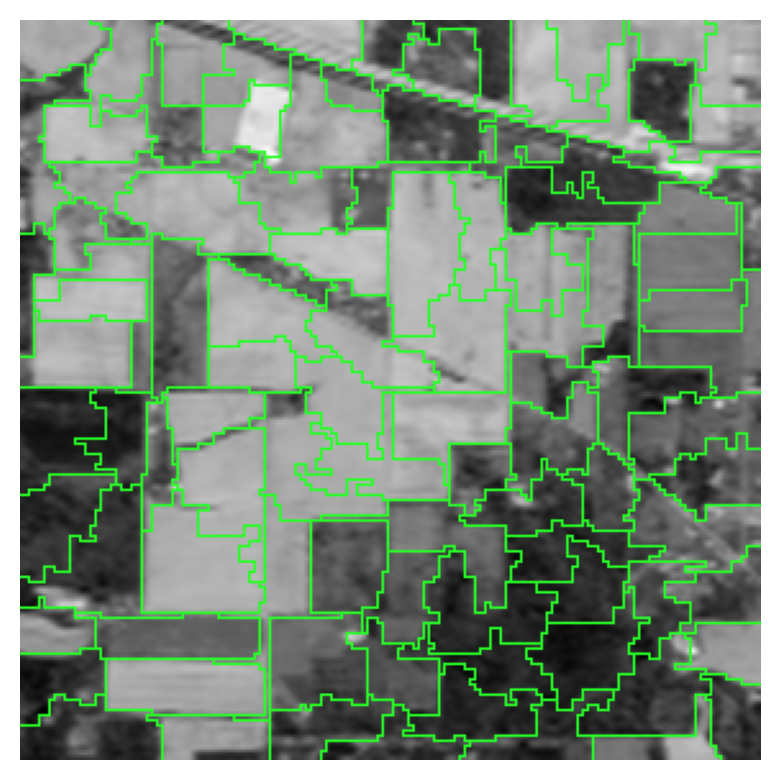

In [355]:
segments = s3pca.segments
from skimage.segmentation import mark_boundaries

fig, ax = pl.subplots(figsize=(5,4))
pl.imshow(mark_boundaries(img_pca, segments,color=(0.15, 1.0, 0.15),mode='subpixel'),cmap='Greys_r')
ax.axis('off')
pl.tight_layout()
pl.savefig("Images/exp4_seg_img.png", dpi = 600)
pl.show()

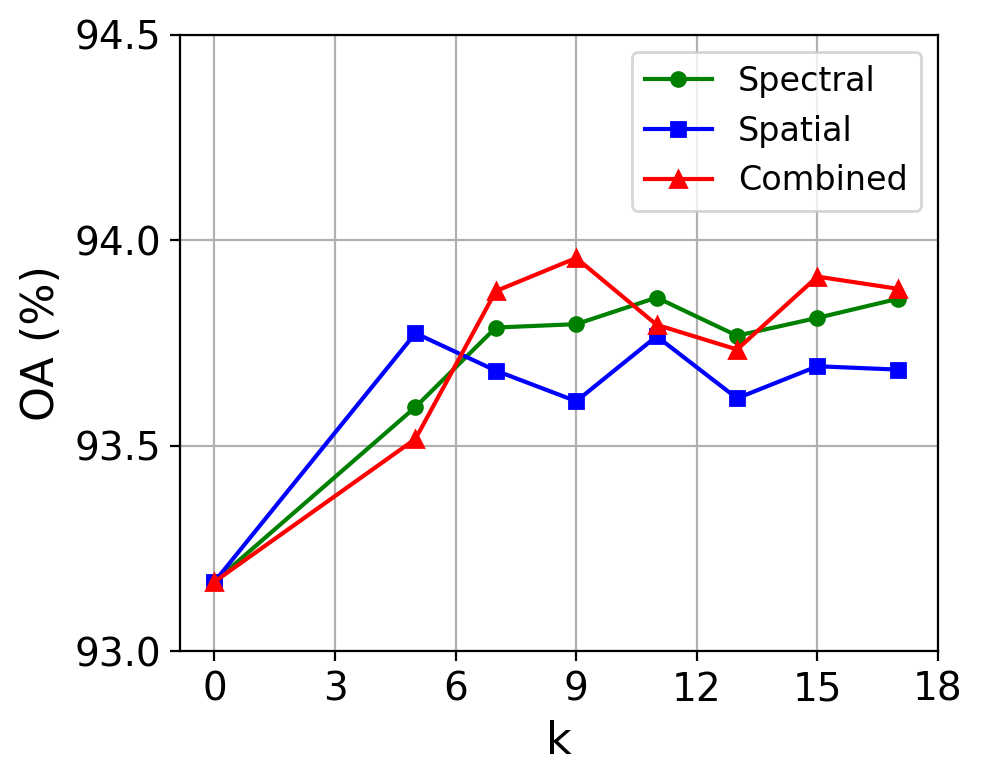

In [353]:
exp5 = pd.read_csv("Experiments/Exp5.csv", index_col=0)

pl.figure(figsize=(5, 4))
for i, method in enumerate(df5.index):
    pl.plot(exp5.columns.astype(int)[:-1], df5.loc[method][:-1]*100, marker=markers[i], color = colors[i], markersize = sizes[i], label=method)

pl.xlabel("k", fontsize=16)
pl.ylabel("OA (%)", fontsize=16)
pl.legend(fontsize=12)
pl.grid(True)
pl.ylim([93, 94.5])
pl.xticks([0, 3, 6, 9, 12, 15, 18], fontsize=14)
pl.yticks([93, 93.5, 94, 94.5], fontsize=14)
pl.tight_layout()
pl.savefig("Images/Exp5.png", dpi=600)
pl.show()